# Final figures for "Global quantification of river confinement"
Introduction, (some) Methods and global map figures are made in QGIS and cannot be found in this node book. Other differences between the figures found in this notebook and figures in the paper stem from final adjustments made in Adobe Illustrator or by the editors.

Final result figures

In [10]:
# Package exports
import os
import sys

import pandas as pd
import duckdb
import geopandas as gpd
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import seaborn as sns
from pathlib import Path
import xarray as xr

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pipeline" / "__init__.py").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root containing pipeline/")

repo_root = _find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pipeline.clustering import print_pca_loadings,\
                        data_prep_clustering, applyGMM, applyKmeans
from pipeline.paths import load_project_paths, format_factor_token

# Prefer an explicit env override; otherwise default to the local project config
# used for the canonical pipeline checks in this repo.
config_override = os.getenv("RIVER_CONFINEMENT_PATHS")
if config_override is None:
    default_local_config = repo_root / "config" / "paths.local.json"
    if default_local_config.exists():
        config_override = str(default_local_config)

project_paths = load_project_paths(config_override)
print(f"Using project config: {project_paths.config_path}")
results_root = project_paths.results_root
figures_dir = results_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


Using project config: /Users/6256481/Code/river-confinement/config/paths.local.json


# Methods

In [12]:
%load_ext autoreload
%autoreload 2
import xml.etree.ElementTree as ET
from pathlib import Path
import sys

# Locate the package even when starting directly in the Methods section.
def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pipeline" / "__init__.py").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root containing pipeline/")

repo_root = _find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pipeline.dem import find_dem_bounds_FAB
from pipeline.build_fabdem_index import build_fabdem_index
from pipeline.get_orthogonals import get_orthogonals
from pipeline.support import adjust_new_segments, confinement_factor_single_values
from osgeo import gdal



from shapely.geometry import LineString, Point, MultiPoint, MultiLineString, Polygon
from shapely import box as Box

import numpy as np
from pipeline.get_orthogonals import get_orthogonals
from pipeline.dem import find_dem_FAB
from tqdm import tqdm
from pipeline.support import get_ids, node_position
import glob
from osgeo import gdal
# from skimage import measure

from scipy.stats import trim_mean
import os
from pipeline.extract_slope_along_raster_line import extract_slope_along_raster_line
from pipeline.line_functions import getExtrapoledLine
from datetime import datetime as dt
from pipeline.inflection_points import inflection_points_curve
from pipeline.smoothing import SG_smoothing
from pipeline.connect_geometries import merge_centerlines
import scipy as sc
from pipeline.run_confinement_values import confinement_factor
from pipeline.dem import get_raster_vrt
from pipeline.calc_functions import confinement_values, mm_to_inch
from datetime import datetime as dt
from scipy.spatial import cKDTree


# Add a colorbar with the proper adjustments
from mpl_toolkits.axes_grid1 import make_axes_locatable

from pipeline.confinement_margin import confinement_margin

from pipeline.calc_functions import x_y_intercept

from pipeline.confinement_margin import get_raster_side
from pipeline.run_confinement_values import calc_confinement_values
from pipeline.get_orthogonals import get_orthogonals
from pipeline.support import create_dir, create_custom_cmap, adjust_new_segments
from pipeline.line_functions import split_ring
from pipeline.dem import find_dem_bounds_FAB

import glob



from pipeline.support import smooth_factor
import warnings
warnings.filterwarnings("ignore")

# Shared plotting imports and paths for running Methods independently.
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import xarray as xr

from pipeline.paths import load_project_paths, format_factor_token

# Prefer an explicit env override; otherwise default to the local project config
# used for the canonical pipeline checks in this repo.
config_override = os.getenv("RIVER_CONFINEMENT_PATHS")
if config_override is None:
    default_local_config = repo_root / "config" / "paths.local.json"
    if default_local_config.exists():
        config_override = str(default_local_config)

project_paths = load_project_paths(config_override)
print(f"Using project config: {project_paths.config_path}")
results_root = project_paths.results_root
figures_dir = results_root / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using project config: /Users/6256481/Code/river-confinement/config/paths.local.json


# Confinement transect figures

In [36]:
directory = '/Volumes/PhD/SWORD/v17b/GPKG/'
dfEU = gpd.read_file(directory + 'eu_sword_reaches_v17b.gpkg')

directory = '/Volumes/PhD/SWORD/v17c/'
dfEUc = gpd.read_parquet(directory + 'sword_EU_v17c_reaches.parquet')

In [37]:
rids = dfEUc[dfEUc['main_path_id'] == 2000168]['reach_id'].to_list()
# rids

In [38]:
tt = df_cfc[df_cfc['reach_id'].isin(rids)]['combined_reach_id'].to_list()

In [ ]:
cont   = 'eu'
contID = '02'
crossFactor = 50
conFactor   = [50,10]
DEMprojection = 'EPSG:4326'

create_new = False
cross_token = format_factor_token(crossFactor)

directory = '/Volumes/PhD/'
vector_save_file = directory + f'confinement/results/new_segments/vector/{cont}_{contID}_reach_new_segments.gpkg'
node_save_file = directory + f'SWORD/v17/GPKG/{cont}_sword_nodes_v17.gpkg'

df_cfc = gpd.read_file(vector_save_file)
dfNode = gpd.read_file(node_save_file)

# adjust str values to int or float
df_cfc   = adjust_new_segments(df_cfc)


In [25]:
# open confinement and smoothing factor
cross_token = format_factor_token(crossFactor)
fname = project_paths.confinement_factor_file_for(crossFactor)
if fname.exists():
    dfCF = pd.read_csv(fname)
else:
    bend_files = np.sort([str(path) for path in project_paths.bends_dir.glob(f'??_??_{cross_token}.parquet')])
    if len(bend_files) == 0:
        raise FileNotFoundError(f'No bend parquet files found for cross factor {cross_token} in {project_paths.bends_dir}')
    dfA = pd.concat([
        pd.read_parquet(f, columns=['bendWidths'])
        for f in bend_files
    ], ignore_index=True)
    dfCF = confinement_factor_single_values(dfA, 'bendWidths', conFactor[0], conFactor[1])
    dfCF.to_csv(fname, index=False)

smooth_factor_file = project_paths.reference_tables_dir / 'smoothingFactor.csv'
if smooth_factor_file.exists():
    dfSF = pd.read_csv(smooth_factor_file)
else:
    smooth_factor(df_cfc, str(project_paths.results_root))
    dfSF = pd.read_csv(smooth_factor_file)


# df_cfc   = adjust_new_segments(df_cfc)
# dfCF = pd.read_csv('/Volumes/PhD/confinement/results/confinement_factor.csv')
# dfSF = pd.read_csv('/Volumes/PhD/confinement/results/smoothingFactor.csv')


In [17]:
vrt_path = project_paths.fabdem_vrt
if vrt_path.exists():
    demVRT   = gdal.Open(str(vrt_path))

    # use if needed
    # update_root_path_dem_vrt(str(project_paths.fabdem_vrt),
    #                      "/home/6256481/River_Morphology/input/FAB_dem/",
    #                      str(project_paths.fabdem_dir),
    #                      str(project_paths.input_created_dem_dir / "FAB_dem_vrt_updated.vrt"))
else:
    build_fabdem_index(config_path=str(project_paths.config_path) if project_paths.config_path is not None else None)
    demVRT   = gdal.Open(str(vrt_path))


In [26]:
def run_var_extraction(id):
        dfReach      = df_cfc[df_cfc['combined_reach_id'] == id].copy()
        dfReachNodes = dfNode[dfNode['reach_id'].isin(dfReach['reach_id'].values)].copy()

        GroupedCRS = dfReach.groupby('localCRS', as_index = False).size()
        reachCRS   = GroupedCRS.loc[GroupedCRS['size'] == GroupedCRS['size'].max()
                                        ,'localCRS'].iloc[0]

        dfReach      = dfReach.to_crs(reachCRS)
        dfReachNodes = dfReachNodes.to_crs(reachCRS)
        df_cfc.loc[dfReach.index, 'combined_reach_crs'] = reachCRS           

        combinedLine, _, _ = merge_centerlines(dfReach, df_cfc, reachCRS)


        ###########################
        # Set width factor value
        ###########################
        widthVar    = 'width'
        factorWidth = dfReach['combined_reach_width'].iloc[0]
        
        if dfReachNodes[widthVar].std() > (factorWidth/2):
                factorWidth = trim_mean(dfReachNodes[widthVar], 0.05)
        if np.isnan(factorWidth):
                factorWidth = dfReachNodes[widthVar].mean()
        ###########################
        # Width Ratio
        ###########################
        widthRatio = dfReachNodes['width'] / dfReachNodes['max_width']
        df_cfc.loc[dfReach.index, 'widthRatio'] = np.nanmean(widthRatio)

        ###########################
        # Smoothing
        ###########################
        factorRow       = abs(dfSF['combined_reach_width'] - factorWidth).argsort()
        smoothingFactor = dfSF.loc[factorRow, 'smoothFactor'].iloc[0]
        
        smoothing_window = smoothingFactor*int(factorWidth) # Smoothing window based on mean node max width
                
        # Smooth centerline
        combinedLine = SG_smoothing(combinedLine, smoothing_window, factorWidth)
        if len(combinedLine.coords) < 3:
                combinedLine = combinedLine.segmentize(1) 
        
        # find node positions along combined centerline
        # add node positions after smoothing for similarity in coding
        dfReachNodes = node_position(combinedLine, dfReachNodes)


        (sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines, 
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc) = inflection_points_curve(combinedLine, dfReach, dfReachNodes)

        

        for i in range(1):
                po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight = get_orthogonals(combinedLine, dfReach, 
                                        apexPList, apexPOList, amplitudes ,infLines,
                                        bendLines, bendWidths,
                                        reachCRS, 'EPSG:4326',
                                        crossFactor, 
                                        -9999,demVRT,
                                        '', 400)
        return (dfReach, combinedLine, po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight,
                sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines, 
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc, reachCRS)


In [27]:
def apexWidth(apexP, dfN):
    dfApex = gpd.GeoDataFrame({'geometry':apexP.buffer(200)}, crs = reachCRS, index = [0])



    lineNodeJoin = gpd.sjoin_nearest(dfApex, dfN)
    bendNodes    = dfN[dfN.node_id.isin(lineNodeJoin.node_id.values)]
    return bendNodes['max_width'].mean()

def plotConnection(dfReach, localCRS, df, ax, zorder = 100):
    maxOrder = dfReach['reach_order'].max()

    for s, o, c, side, style in [['up', 0, 'red', 'upstream', '--'], ['dn', maxOrder, 'red', 'red', '--']]:
        rch = dfReach.loc[dfReach['reach_order'] == o, f'rch_id_{s}'].iloc[0]
        if isinstance(rch, list):
            dfS = df.loc[df.reach_id.isin(rch)]
            dfS = dfS.to_crs(localCRS)
            if side == 'upstream':
                dfS.plot(ax =ax, color = c, zorder = zorder, linewidth = 2, linestyle = style, label = 'Connecting Reach')
            else:
                dfS.plot(ax =ax, color = c, zorder = zorder, linewidth = 2, linestyle = style)
            # l = dfS.iloc[0].geometry
            # ax.plot(*l.xy, zorder = zorder,color =  'red')

def plotExtraLine(df, rid, localCRS):
    dfReach = df[df['reach_id'] == rid].copy()
    dfReach = dfReach.to_crs(localCRS)
    line = dfReach.iloc[0]['geometry']
    return line

In [28]:
def plot(apexID,row,hf, plotProf =True, plotDEM = True, figureType = 'Regular',
         hillshade=True, hillshade_alpha=0.3, hillshade_mode='overlay'):
    """Plot with optional 'overlay' or 'soft_light' shading; alpha sets strength (0–1)."""
    if hillshade_mode not in {'overlay', 'soft_light'}:
        raise ValueError("hillshade_mode must be 'overlay' or 'soft_light'.")
    if not 0 <= hillshade_alpha <= 1:
        raise ValueError('hillshade_alpha must be between 0 and 1.')
    # Shared styling also supports plotting only the DEM.
    axis_label_size, textSize, axis_tick_size = 15, 15, 12
    outsideColor = innsideColor = 'dimgray'
    def plot_prep(apexID):
        bendMW = bendMaxWidths[apexID]
        bendW  = bendWidths[apexID]

        heightFactor    = hf
        factorRow       = abs(dfCF['bendWidths'] - bendW).argsort()
        # 4.429160868401368
        
        conFactor = dfCF.loc[factorRow.iloc[0], 'conFactor'] * heightFactor

        maxSlope1 = (conFactor*bendW) / (0.5*bendW)

        
        (poIntercept, piIntercept,
        centerPointHeight, confinementHeight,
        slopeOut, slopeInn, EROut, ERInn) = confinement_values(po[apexID], pi[apexID], 
                                                    cdo[apexID], cdi[apexID], 
                                                                bendW, bendMW, conFactor)
        maxSlope2 = (confinementHeight-centerPointHeight) / (0.5*bendW)
        # print(maxSlope1, maxSlope2, poIntercept, piIntercept, conFactor)
        # print('Width/confheight:'.ljust(30), np.round(bendMW,5), np.round(bendMW*conFactor,5))
        # rowcm = pd.DataFrame({'localCRS':reachCRS, 'bendMaxWidths':bendMW,'bendWidths':bendW, 
        #                     'bendLines':bendLines[apexID], 'conFactor':conFactor}, index = [0])
        # r, r1, r2 = get_raster_side(combinedLine, demVRT, np.max(bendMW) * 2, reachCRS)
        # (confDistance, confDistanceLeft, 
        # confDistanceRight, bendHeight, 
        # pLeft, pRight) = confinement_margin(rowcm.iloc[0], r, r1, r2, 2, heightFactor, 10)
        demWidth        = np.max(bendW)
        rasterSize = demWidth*crossFactor if demWidth*crossFactor < 30000 else 30000*1.2
        raster = get_raster_vrt(demVRT, row, rasterSize*1.5, reachCRS, DEMprojection)
        return (poIntercept, piIntercept,
                centerPointHeight, confinementHeight,
                slopeOut, slopeInn, EROut, ERInn, raster, maxSlope2, bendW, bendMW)
    
    (poIntercept, piIntercept,
        centerPointHeight, confinementHeight,
        slopeOut, slopeInn, EROut, ERInn, raster, maxSlope, bendW, bendMW) = plot_prep(apexID)
    
    print('Confinement Ratio (in, out):'.ljust(30), np.round(ERInn,5), np.round(EROut,5))
    print('Slope (in, out):'.ljust(30), np.round(slopeInn,5), np.round(slopeOut, 5))
    print('Normalized Slope (in, out):'.ljust(30), np.round(slopeInn / maxSlope,5), np.round(slopeOut / maxSlope, 5))
    print('max slope m/m :'.ljust(30), np.round(maxSlope,5))
    # print('Slope degree (in, out):'.ljust(30), np.round(np.rad2deg(np.arctan(slopeOut * maxSlope)),5), np.round(np.rad2deg(np.arctan(slopeInn * maxSlope)), 5))

    if plotProf == True:
        #####
        # plot settings:
        axis_label_size = 15
        textSize        = 15
        axis_tick_size  = 12

        outsideColor = 'dimgray'
        innsideColor = 'dimgray'

        ############################################################
        ############################################################
        # Figure 1
        ############################################################
        ############################################################
        print('???', leftRightConf[apexID])
        if leftRightConf[apexID] == 1:
            pl, cl   = po[apexID], cdo[apexID]
            pr, cr   = pi[apexID], cdi[apexID]
            plI, prI = poIntercept, piIntercept
            leftText, rightText = 'Outer', 'Inner'
        else:
            pl, cl = pi[apexID], cdi[apexID]
            pr, cr = po[apexID], cdo[apexID]
            plI, prI = piIntercept, poIntercept
            leftText, rightText = 'Inner', 'Outer'


        minH = min(min(pl), min(pr))
        maxH = max(max(pl), max(pr))
        # if figureType == 'Methods':
        #     figWidth, figHeight = mm_to_inch(68), mm_to_inch(52)
        # elif figureType in ['Unconfined', 'Confined', 'PartialOS', 'Partial']:
        #     figWidth, figHeight = mm_to_inch(68), mm_to_inch(52)
        # else:
        figWidth, figHeight = [8,6]
        print(cl)
        print(pl)
        f, ax1 = plt.subplots(nrows = 1, ncols = 1, figsize = [figWidth, figHeight])
        ax1.plot(np.array(cl)*-1, pl, color = 'black', zorder = 0)
        ax1.plot(cr             , pr, color = 'black', zorder = 0)
        


        ##################### 
        # Slope lines ( not adjusted for Left Right)
        # if np.isnan(EROut) == False:
        #     yo = [centerPointHeight, confinementHeight]
        #     xo = [0, poIntercept]
        # else:
        #     yo = centerPointHeight + slopeOut * (cdo[apexID] - cdo[apexID][0])
        #     xo = cdo[apexID]
            
        # if np.isnan(ERInn) == False:
        #     yi = [centerPointHeight, confinementHeight]
        #     xi = [0, piIntercept*-1]
            
        # else:
        #     yi = centerPointHeight + slopeInn * (cdi[apexID] - cdi[apexID][0])
        #     xi = np.array(cdi[apexID])*-1
        # ax1.plot(xo, yo, color = 'blue', label = f'Out: {slopeOut}', zorder = 200)
        # ax1.plot(xi, yi, color = 'blue', label = f'In: {slopeInn}' , zorder = 200)
        
        #####################
        # River extend lines
        ax1.vlines(bendW/2     , minH, maxH, linestyle = '--', color = '#848484', zorder = 10)
        ax1.vlines((bendW/2)*-1, minH, maxH, linestyle = '--', color = '#848484', zorder = 10)

        # plt.axvline(bendW*5, color='g', linestyle="--")
        # plt.axvline(bendW*-5, color='g', linestyle="--")
        #####################
        # confinement height line
        if figureType in ['Unconfined', 'Methods', 'Regular']:
            ax1.hlines(confinementHeight, max(cl)*-1, max(cdo[apexID]), linestyle = '--', color = 'red', zorder = 100)
        else:
            ax1.hlines(confinementHeight, plI*-1, prI, linestyle = '--', color = 'red', zorder = 100)

        #####################
        # River centerpoint
        ax1.scatter(0, centerPointHeight, marker = '^', c = 'red', s = 150
                    , zorder = 500)
        
        #######################################
        if figureType == 'Methods':
            # paper methods figure settings
            # dist, minH, maxH = 400, 700, 800
            # xLim2 = xLim1
            # ax1.set_xticks(np.arange(-1*dist, dist+100, 100), [400,300,200,100,0,100,200,300,400])
            # loc = [0.5,0.98]
            axis_label_size = 15
            textSize        = 15
            axis_tick_size  = 12

            xLim1, xRange, minH, maxH,xstep,ystep = 250, 300, 700, 800,100,20
            xLim2 = xLim1
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.3,0.7,0.7]

        elif figureType == 'Unconfined':
            # Paper results unconfined
            xLim1, xRange, minH, maxH,xstep,ystep = 1500, 8000, -8, 192,2000,5
            xLim2 = xLim1
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.3,0.7,0.7]
        elif figureType == 'Partial':
            # Paper results Partial cluster 4
            xLim1, xRange, minH, maxH,xstep,ystep = 1500, 600, 300, 500,200,10
            xLim2 = xLim1
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.3, 0.7,0.7]
        elif figureType == 'PartialOS':
                # Paper results partial one sided
            xLim1, xRange, minH, maxH,xstep,ystep = 1200, 1500, 220, 420,500,20
            xLim2 = 1800
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.1,0.65,0.6]
        elif figureType == 'Confined':
                # Paper results confined
            xLim1, xRange, minH, maxH,xstep,ystep = 1500, 1500, 60, 260, 500, 50
            xLim2 = xLim1
            ax1.set_xticks(np.arange(-1*xRange, xRange+xstep, xstep), np.append(np.arange(xRange, 0,-1*xstep), np.arange(0, xRange+xstep, xstep)))
            ax1.set_yticks(np.arange(minH+ystep, maxH, ystep), np.arange(minH+ystep, maxH, ystep))
            loc = [0.25,0.85,0.8]
        else:
            xLim1, xLim2 = max(cdi[apexID])*-1, max(cdo[apexID])
            loc = [0.3,0.7,0.7]

        if figureType in ['Unconfined', 'Confined', 'PartialOS', 'Partial']:
            ax1.axis('off') 
            print(f'XRange: {xLim1 + xLim2}, YRange: {maxH-minH}, VI: {(xLim1 + xLim2) / (maxH-minH)}')
             # print(xLim1, xLim2)
            ax1.set_xlim([-1*xLim1,xLim2])
            ax1.set_ylim([minH, maxH])
        elif figureType in ['Methods']:
            ax1.axis('on') 
            ax1.set_xlim([-1*xLim1,xLim2])
            ax1.set_ylim([minH, maxH])
        else:
            ax1.axis('on') 
            ax1.set_xlim([-1000,1000])

       

        #######################################
        # text
        ax1.text(loc[0], loc[2], f"Left\n{leftText}"  , fontsize=textSize, color='black', ha="center", zorder = 300, transform=ax1.transAxes)
        ax1.text(loc[1], loc[2], f"Right\n{rightText}", fontsize=textSize, color='black', ha="center", zorder = 300, transform=ax1.transAxes)
        
        #######################################
        #labels Distance (m) Elevation (m)
        ax1.set_xlabel(''  , fontsize = axis_label_size)
        ax1.set_ylabel('' , fontsize = axis_label_size)
        # Customize tick size and color
        ax1.tick_params(axis='both', which='major', labelsize=axis_tick_size, colors='black')  # Major ticks
        
        plt.tight_layout()
        if figureType == 'Regular1':
            plt.savefig(figures_dir / 'confinement_profile.svg', dpi=1000, bbox_inches = 'tight')
        else:
            plt.savefig(figures_dir / f'confinement_profile_{figureType}.png', dpi=1000, bbox_inches = 'tight')
        # plt.savefig('/home/6256481/River_Morphology/' + 
                    # f'results/figures/confinement_metric.png', dpi=1000)
        plt.show()
        # fig_width_mm = f.get_size_inches()[0] * 25.4
        # print(fig_width_mm)
    if plotDEM == True:
        ############################################################
        ############################################################
        # Figure 2
        ############################################################
        ############################################################
        f, ax2 = plt.subplots(nrows = 1, ncols = 1, figsize = [8,8])
        

        ##############################
        # Plot centerline
        ax2.plot(*combinedLine.xy, zorder =10, color = 'red', linewidth = 3, label = 'Centerline')

        ##############################
        # Plot Apex points
        pointSize = 120
        for i, ap in enumerate(apexPList):
            if i != apexID:
                ax2.scatter(*ap.xy, c = 'black', marker = '^', zorder = 100, s= pointSize)
        ax2.scatter(*apexPList[apexID].xy, c = 'black', marker = '^', zorder = 1000, s = pointSize, label = 'Bend apex')


        ##############################
        # confinement lines
        ax2.plot(*lineOut[apexID].xy, color = outsideColor, label = 'Outer (Right)', linewidth = 2, linestyle = '--')
        ax2.plot(*lineInn[apexID].xy, color = innsideColor, label = 'Inner (Left)', linewidth = 2)


        ##############################
        # Plot extra line
        # for rid in [23269000441, 23269000401]:
        #     if rid in df['reach_id'].values:
        #         L = plotExtraLine(df, rid, reachCRS)
        #         ax2.plot(*L.xy, linewidth = 1, color = 'red', linestyle = '--')


        ##############################
        # axis settings
        ax2.set_aspect('equal')
        ax2.axis('off')

        ##############################
        # plot Raster
        rasterValues = raster[:,:]
        rasterValues = rasterValues.values.ravel()
        vmin = rasterValues[rasterValues != -9999].min()
        im = raster.plot(ax = ax2, vmin = vmin, vmax = raster.max(), cmap = 'terrain', zorder = 0,
                    add_colorbar=False)
        if hillshade and hillshade_alpha > 0:
            from matplotlib.colors import LightSource

            # North at the top; coordinate spacing and elevations are in metres.
            shade_dem = raster.transpose('y', 'x').sortby('x').sortby('y', ascending=False)
            elevation = shade_dem.values.astype(float)
            valid = np.isfinite(elevation) & (elevation != -9999)
            if valid.any() and min(elevation.shape) >= 2:
                dx = float(np.abs(np.diff(shade_dem.x.values)).mean())
                dy = float(np.abs(np.diff(shade_dem.y.values)).mean())
                light = LightSource(azdeg=315, altdeg=45)
                intensity = light.hillshade(
                    np.ma.array(elevation, mask=~valid), dx=dx, dy=dy,
                )
                shade = shade_dem.copy(data=np.ma.filled(intensity, np.nan))
                shade = shade.where(valid)
                if hillshade_mode == 'overlay':
                    shade.plot(ax=ax2, cmap='gray', vmin=0, vmax=1,
                               alpha=hillshade_alpha, zorder=1, add_colorbar=False)
                else:
                    # Use the same elevation colours and normalization as the colourbar.
                    rgb = im.cmap(im.norm(elevation))[..., :3]
                    illumination = np.nan_to_num(shade.values, nan=0.5)[..., None]
                    blended = light.blend_soft_light(rgb, illumination)
                    mixed = (1 - hillshade_alpha) * rgb + hillshade_alpha * blended
                    rgba = np.dstack((mixed, np.isfinite(shade.values).astype(float)))
                    ax2.pcolormesh(shade_dem.x.values, shade_dem.y.values, rgba,
                                   shading='auto', zorder=1)

        ax2.set_title('')


        ##############################
        # Colorbar
        divider = make_axes_locatable(ax2)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(im, cax=cax, shrink=0.8, aspect=10)
        cbar.ax.tick_params(labelsize=axis_tick_size)  # Adjust tick label text size
        cbar.set_label(' ', fontsize=axis_label_size, labelpad=10)
        
        ##############################
        # Legend
        times_font = FontProperties(family='Times New Roman', size=14)
        ax2.legend(fontsize = axis_label_size, prop=times_font, loc='lower right')

        ##############################
        # Get current limits
        x0, x1 = ax2.get_xlim()
        y0, y1 = ax2.get_ylim()
        # Percentage to trim
        trim_pct = 0.02  # 2%
        # Adjust limits by trimming a percentage
        x_range = x1 - x0
        y_range = y1 - y0
        ax2.set_xlim(x0 + x_range * trim_pct, x1 - x_range * trim_pct)
        ax2.set_ylim(y0 + y_range * trim_pct, y1 - y_range * trim_pct)

        ##############################
        # save image
        plt.tight_layout()
        plt.savefig(figures_dir / f'confinement_metric_dem_{figureType}.png', dpi= 1000, bbox_inches = 'tight')
        plt.show()

# Methods

In [21]:
rid = 6130

dfReach, combinedLine, po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight,\
         sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines,\
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc, reachCRS = run_var_extraction(rid)

Confinement Ratio (in, out):   2.86919 5.44029
Slope (in, out):               0.29985 0.15814
Normalized Slope (in, out):    0.17427 0.09191
max slope m/m :                1.72065
??? 0.0
[0.0, 5.625, 11.25, 16.875, 22.5, 28.125, 33.75, 39.37500000000001, 45.0, 50.625, 56.25, 61.875, 67.5, 73.125, 78.75000000000001, 84.375, 90.0, 95.625, 101.25, 106.875, 112.5, 118.125, 123.75, 129.375, 135.0, 140.625, 146.25, 151.875, 157.50000000000003, 163.125, 168.75, 174.375, 180.0, 185.625, 191.25, 196.875, 202.5, 208.125, 213.75, 219.375, 225.0, 230.625, 236.25, 241.875, 247.5, 253.125, 258.75, 264.375, 270.0, 275.625, 281.25, 286.875, 292.5, 298.125, 303.75, 309.375, 315.00000000000006, 320.625, 326.25, 331.875, 337.5, 343.125, 348.75, 354.375, 360.0, 365.625, 371.25, 376.875, 382.5, 388.12499999999994, 393.75, 399.375, 405.0, 410.625, 416.25, 421.875, 427.5, 433.125, 438.75, 444.375, 450.0, 455.62500000000006, 461.25, 466.875, 472.5, 478.125, 483.75, 489.375, 495.0, 500.625, 506.25, 511.875, 5

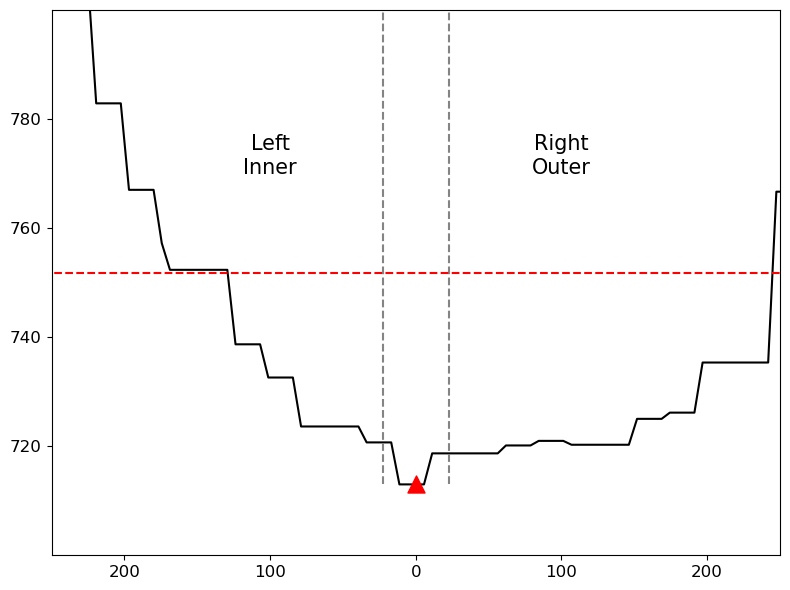

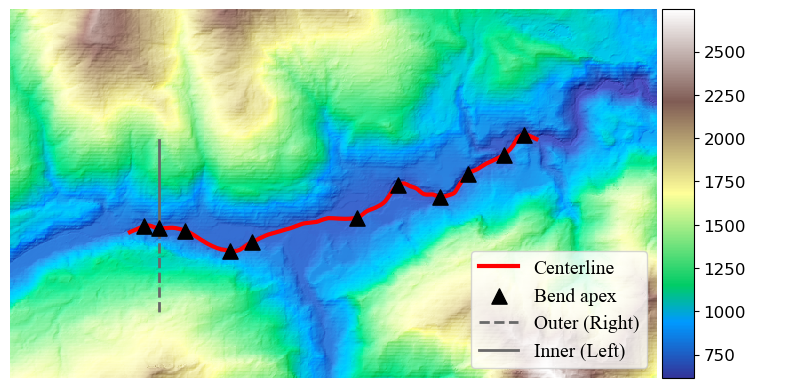

In [22]:
figureType = 'Methods' # 6130
plot(1, dfReach,10, True, True, figureType, hillshade_mode='soft_light', hillshade_alpha=1)


# Results

## Transect examples figures

### Unconfined

Confinement Ratio (in, out):   nan nan
Slope (in, out):               -1e-05 4e-05
Normalized Slope (in, out):    -8e-05 0.00056
max slope m/m :                0.08
??? 1.0
[0.0, 35.16126943889988, 70.32253887779976, 105.48380831669964, 140.64507775559952, 175.80634719449938, 210.96761663339927, 246.12888607229914, 281.29015551119903, 316.45142495009884, 351.6126943888824, 386.77396382778227, 421.93523326668213, 457.09650270558194, 492.2577721444819, 527.4190415833817, 562.5803110222816, 597.7415804611816, 632.9028499000813, 668.0641193389812, 703.2253887778811, 738.386658216781, 773.5479276556808, 808.7091970945808, 843.8704665334807, 879.0317359723805, 914.1930054112804, 949.3542748501802, 984.5155442890803, 1019.6768137278941, 1054.838083166794, 1089.9993526056937, 1125.1606220445938, 1160.3218914834936, 1195.4831609223934, 1230.6444303612932, 1265.805699800193, 1300.9669692390928, 1336.1282386779928, 1371.2895081168926, 1406.4507775557925, 1441.6120469946925, 1476.7733164335923, 15

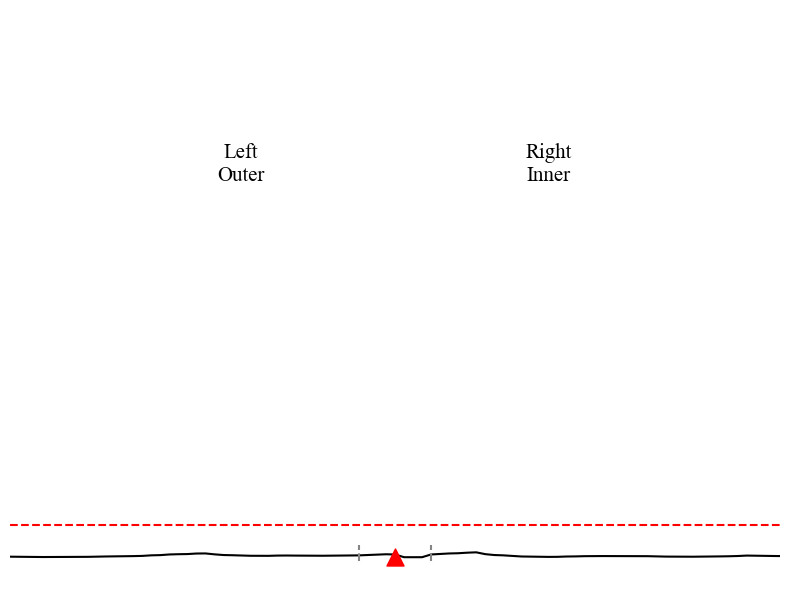

In [93]:
dfReach_unc, combinedLine, po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight,\
         sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines,\
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc, reachCRS = run_var_extraction(5847.0)

figureType = 'Unconfined' 
plot(0, dfReach_unc, 2, True, False, figureType, hillshade_mode='soft_light', hillshade_alpha=1)

### Partial symmetrical confinement

In [34]:
clusters = 7
dfCluster = applyGMM(dfCluster, ['PCA1', 'PCA2', 'PCA3'], clusters, 'kmeans', 100, 'tied', 5)


In [89]:
T = dfCluster[(dfCluster['file'] == 'eu') & (dfCluster['combined_reach_id'].isin(tt))]

In [90]:
T[T['GMM_7_hard'] == 1][['combined_reach_id', 'bendRank', 'ER_inn', 'ER_out']]

,combined_reach_id,bendRank,ER_inn,ER_out
200283,5847.0,1,NaN,NaN
200284,5847.0,2,NaN,NaN
200286,5847.0,4,NaN,NaN
200287,5847.0,5,NaN,NaN
200288,5848.0,1,NaN,NaN
...,...,...,...,...
202031,15654.0,1,37.996754,36.807750
202032,15655.0,1,1.354393,13.287158
202033,15656.0,1,34.922717,31.696634
202034,15657.0,1,16.400491,29.345376


In [83]:
# for index, row in T[T['GMM_7_hard'] == 3][['combined_reach_id', 'bendRank', 'ER_inn', 'ER_out']].iterrows():
#     print(f"Combined Reach ID: {row['combined_reach_id']}, Bend Rank: {row['bendRank']}", {row['ER_inn']}, {row['ER_out']})
#     # if row['ER_inn'] > 2.0 and row['ER_out'] > 2.0:
#     #     print(f"Both ER_inn and ER_out are greater than 2.0 for Reach ID: {row['combined_reach_id']}")
#     # elif row['combined_reach_id'] == 6072:
#     #     print(f"Combined Reach ID: {row['combined_reach_id']}, Bend Rank: {row['bendRank']}", {row['ER_inn']}, {row['ER_out']})

#     dfReach_ps, combinedLine, po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight,\
#          sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines,\
#                 infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc, reachCRS = run_var_extraction(int(row['combined_reach_id']))
#     figureType = 'Regular' 
#     plot(int(row['bendRank'])-1, dfReach_ps,2, True, False, figureType, hillshade_mode='soft_light', hillshade_alpha=1)

Confinement Ratio (in, out):   6.82745 2.92341
Slope (in, out):               0.0101 0.02359
Normalized Slope (in, out):    0.07323 0.17103
max slope m/m :                0.1379
??? 0.0
[0.0, 15.685656070584916, 31.37131214116983, 47.05696821175474, 62.74262428319958, 78.4282803537845, 94.11393642436941, 109.79959249495435, 125.48524856553925, 141.17090463612416, 156.856560706735, 172.54221677815391, 188.22787284873883, 203.91352891932374, 219.5991849899087, 235.2848410604936, 250.9704971310785, 266.65615320168934, 282.34180927310825, 298.0274653436932, 313.71312141427813, 329.39877748486305, 345.0844335554479, 360.77008962605873, 376.45574569664365, 392.1414017680625, 407.8270578386475, 423.51271390923245, 439.1983699798174, 454.88402605040227, 470.56968212101305, 486.2553381915981, 501.94099426301693, 517.6266503336018, 533.3123064041868, 548.9979624747717, 564.6836185453566, 580.3692746159674, 596.0549306873864, 611.7405867579713, 627.4262428285563, 643.1118988991411, 658.7975549697

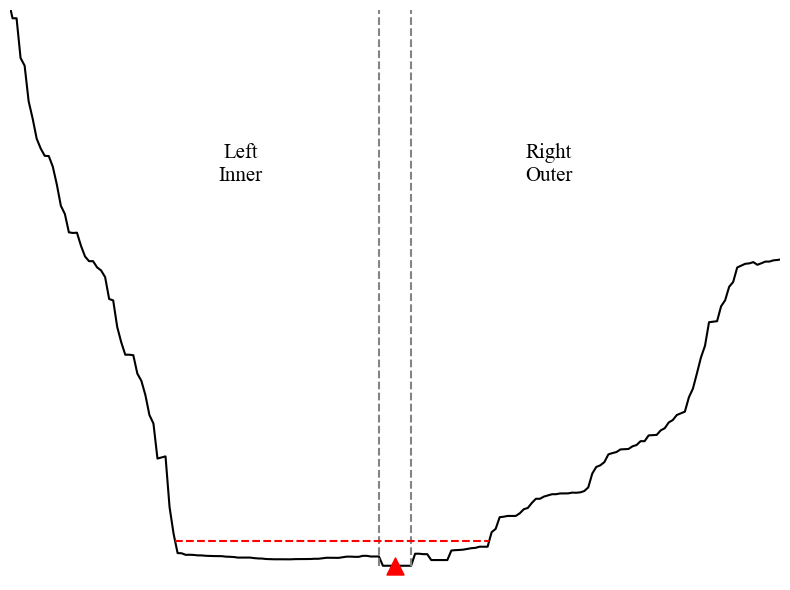

In [84]:
dfReach_ps, combinedLine, po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight,\
         sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines,\
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc, reachCRS = run_var_extraction(6072)
figureType = 'Partial' 
plot(2, dfReach_ps,2, True, False, figureType, hillshade_mode='soft_light', hillshade_alpha=1)


### Partial assymetrical confinement

In [85]:
dfReach_pa, combinedLine, po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight,\
         sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines,\
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc, reachCRS = run_var_extraction(6012)


Confinement Ratio (in, out):   15.96426 0.5
Slope (in, out):               0.00533 0.17008
Normalized Slope (in, out):    0.03132 1.0
max slope m/m :                0.17008
??? 1.0
[0.0, 12.510416666273068, 25.020833333452188, 37.531249999725254, 50.041666666904376, 62.55208333315052, 75.06250000032962, 87.5729166666027, 100.08333333378182, 112.59375000005487, 125.10416666632796, 137.61458333350708, 150.12499999978013, 162.6354166669593, 175.1458333332054, 187.65625000038452, 200.16666666665762, 212.67708333293064, 225.18750000010974, 237.69791666638284, 250.20833333356194, 262.71874999983504, 275.22916666701417, 287.7395833332872, 300.2500000004394, 312.76041666671244, 325.27083333298555, 337.7812500001647, 350.2916666664377, 362.80208333361685, 375.3124999998899, 387.822916667069, 400.3333333333421, 412.84374999958817, 425.35416666676736, 437.8645833330404, 450.3750000002195, 462.8854166664926, 475.39583333367176, 487.90624999994486, 500.41666666621785, 512.927083333397, 525.43749999

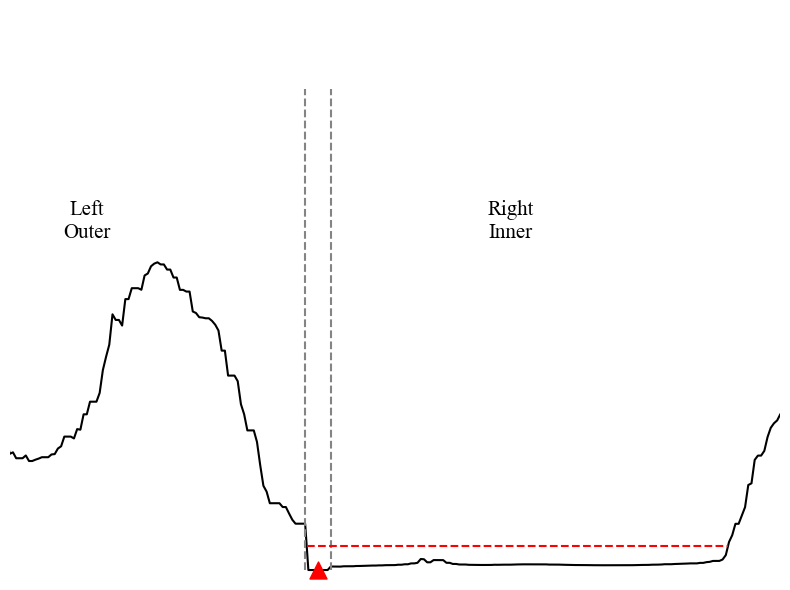

In [86]:

figureType = 'PartialOS' # 6130
plot(6, dfReach_pa,2, True, False, figureType, hillshade_mode='soft_light', hillshade_alpha=1)


### Confined

In [87]:
dfReach_cf, combinedLine, po,pi,cdo, cdi,lineOut, lineInn, leftRightConf, lineSlope, bendHeight,\
         sin, bendSin,inf, infT, amplitudes, apexPList, apexPOList, curveList, bendLines,\
                infLines,bendWidths, bendMaxWidths, bendDO, bendLen, bendFacc, reachCRS = run_var_extraction(5862)


Confinement Ratio (in, out):   0.69418 0.91303
Slope (in, out):               0.05762 0.04381
Normalized Slope (in, out):    0.72028 0.54763
max slope m/m :                0.08
??? 0.0
[0.0, 33.70726284234478, 67.41452568472653, 101.12178852707132, 134.82905136941608, 168.5363142110416, 202.24357705342337, 235.95083989576815, 269.6581027381129, 303.3653655804577, 337.07262842283944, 370.7798912651842, 404.487154107529, 438.1944169499108, 471.90167979225555, 505.60894263388104, 539.3162054762258, 573.0234683186077, 606.7307311609525, 640.4379940032971, 674.1452568456789, 707.8525196880237, 741.5597825303684, 775.2670453727131, 808.9743082143756, 842.6815710567205, 876.3888338990653, 910.0960967414101, 943.803359583792, 977.5106224261366, 1011.2178852684815, 1044.9251481108631, 1078.632410953208, 1112.3396737955527, 1146.0469366371783, 1179.7541994795602, 1213.461462321905, 1247.1687251642495, 1280.8759880065943, 1314.583250848976, 1348.290513691321, 1381.9977765336655, 1415.705039376047

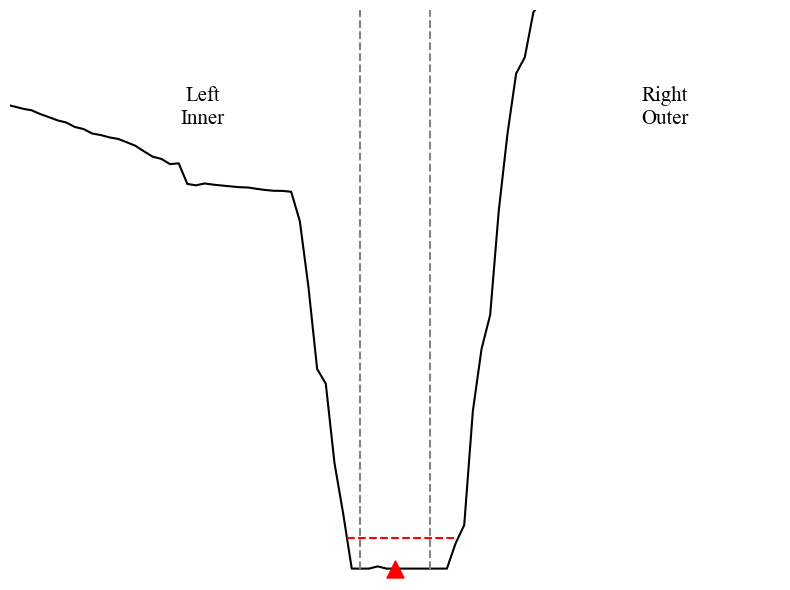

In [88]:

figureType = 'Confined' 
plot(0, dfReach_cf,2, True, False, figureType, hillshade_mode='soft_light', hillshade_alpha=1)


In [ ]:
# unconfined,partial,  partial OS, confined
# 5882, 6028, 6012, 5862
# 5/1/6/0

# Methods 6130 - 
figureType = 'Methods' # 6130
# figureType = 'Unconfined' #5882
# figureType = 'Partial' # 6028
# figureType = 'PartialOS' # 6012
# figureType = 'Confined' #5862
if figureType == 'Methods':
    apex_id = 1
if figureType == 'Unconfined':
    apex_id = 5
if figureType == 'Partial':
    apex_id = 1
if figureType == 'PartialOS':
    apex_id = 6
if figureType == 'Confined':
    apex_id = 0

## Load confinement results

In [31]:
CH = 2
hf_token = format_factor_token(CH)

f = project_paths.single_smoothed_dir / f"global_50_{hf_token}_smoothed.nc"
ds = xr.open_dataset(f)
df = ds.to_dataframe().reset_index()


In [32]:
df['slope_max'] = (df['cm_height'] - df['cp_height']) / (df['bendWidths']*0.5)
df['slope_out_normalized']   = df['slope_out']   / df['slope_max']
df['slope_inn_normalized']   = df['slope_inn']   / df['slope_max']
df['slope_left_normalized']  = df['slope_left']  / df['slope_max']
df['slope_right_normalized'] = df['slope_right'] / df['slope_max']

In [33]:
slopeCols   = ['slope_out_normalized', 'slope_right_normalized', 'slope_left_normalized', 'slope_inn_normalized']
slopeSCols  = ['slope_out_normalized_smooth', 'slope_right_normalized_smooth', 'slope_left_normalized_smooth', 'slope_inn_normalized_smooth']
slopeECols  = ['ER_out', 'ER_left', 'ER_inn', 'ER_right']

dfCluster, pca, Xpca = data_prep_clustering(df, slopeCols+slopeSCols,True, 3, False)

## Contour plots for width vs elevation with Confinement slope and ratio as contours


slope_diff_normalized: raw finite values: n=1484737, range=[-2.01136, 2.95487], outside +/-2=11
After coordinate/width filtering: n=1479374, range=[-2.01136, 2.95487], outside +/-2=11
Smoothed averages before support mask: range=[-0.310026, 1.19581]
Smoothed averages after support mask: n=10851 cells, range=[-0.105746, 0.285721]
Shared contour/colorbar levels:
[-0.15 -0.1  -0.05  0.05  0.1   0.15  0.2   0.25  0.3 ]
Band [-0.15, -0.1]: 1 grid cells (0.01% of supported cells; not contour area)
Band [-0.1, -0.05]: 19 grid cells (0.18% of supported cells; not contour area)
Band [-0.05, 0.05]: 6365 grid cells (58.66% of supported cells; not contour area)
Band [0.05, 0.1]: 3440 grid cells (31.70% of supported cells; not contour area)
Band [0.1, 0.15]: 979 grid cells (9.02% of supported cells; not contour area)
Band [0.15, 0.2]: 34 grid cells (0.31% of supported cells; not contour area)
Band [0.2, 0.25]: 12 grid cells (0.11% of supported cells; not contour area)
Band [0.25, 0.3]: 1 grid cell

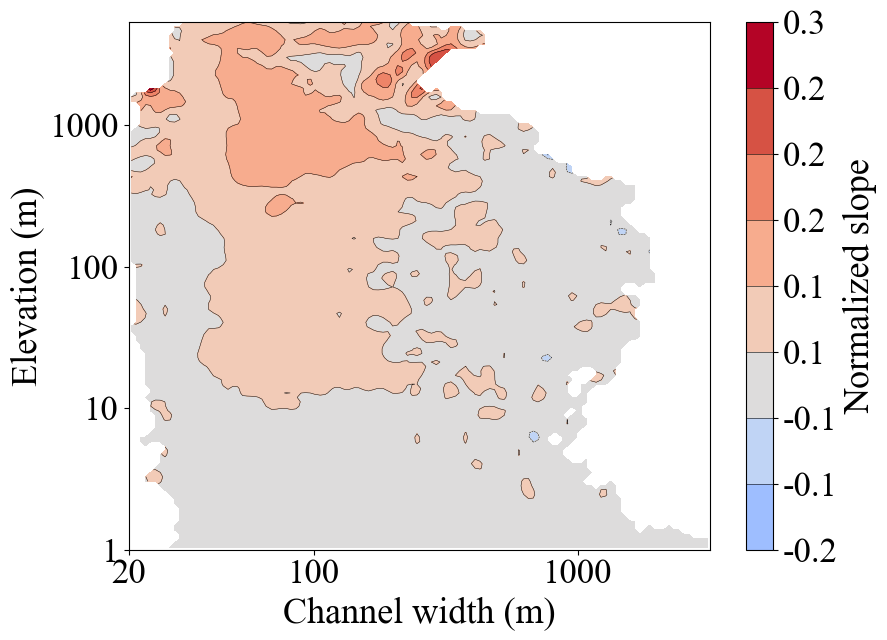


Variable: slope_diff_normalized

Option 1: geometric centers
Level  0 [-0.15, -0.10] | log center = (2.886, 2.795) | original center = (767.84, 622.31)
Level  1 [-0.10, -0.05] | log center = (2.997, 1.999) | original center = (991.65, 98.83)
Level  2 [-0.05, 0.05] | log center = (2.357, 1.265) | original center = (226.31, 17.42)
Level  3 [0.05, 0.10] | log center = (2.022, 2.274) | original center = (104.26, 186.89)
Level  4 [0.10, 0.15] | log center = (1.947, 3.119) | original center = (87.43, 1313.50)
Level  5 [0.15, 0.20] | log center = (2.311, 3.385) | original center = (203.66, 2426.93)
Level  6 [0.20, 0.25] | log center = (2.282, 3.422) | original center = (190.58, 2640.30)
Level  7 [0.25, 0.30] | log center = (1.382, 3.263) | original center = (23.13, 1831.68)

Option 3: density-peak centers
Level  0 [-0.15, -0.10] | log peak = (2.886, 2.795) | original peak = (767.84, 622.31)
Level  1 [-0.10, -0.05] | log peak = (2.868, 1.358) | original peak = (736.06, 21.82)
Level  2 [-0.05,

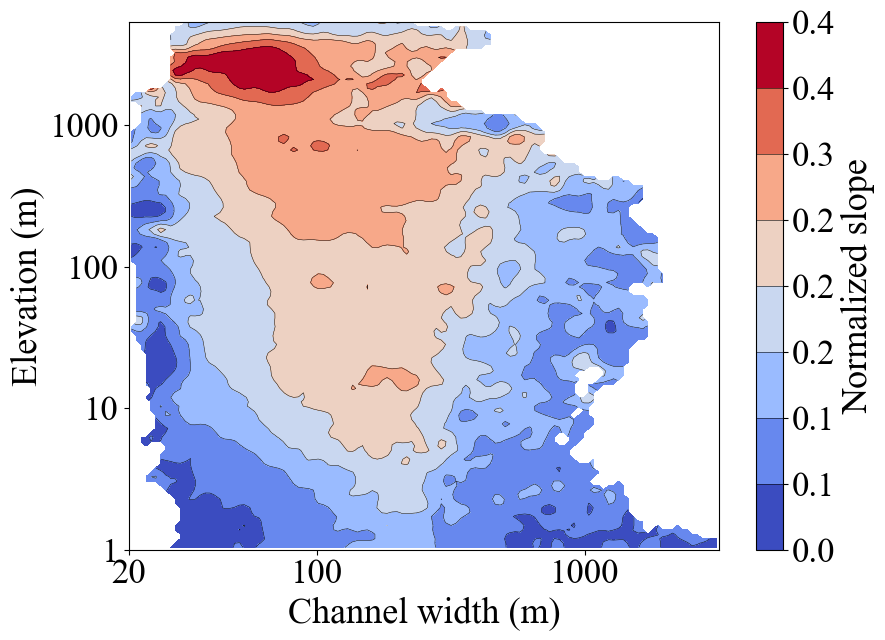


Variable: slope_diff_abs_normalized

Option 1: geometric centers
Level  0 [0.00, 0.05] | log center = (2.006, 0.549) | original center = (100.30, 2.54)
Level  1 [0.05, 0.10] | log center = (2.379, 0.914) | original center = (238.48, 7.21)
Level  2 [0.10, 0.15] | log center = (2.413, 1.457) | original center = (258.10, 27.66)
Level  3 [0.15, 0.20] | log center = (2.153, 1.843) | original center = (141.33, 68.68)
Level  4 [0.20, 0.25] | log center = (2.147, 2.065) | original center = (139.39, 115.10)
Level  5 [0.25, 0.30] | log center = (2.084, 2.789) | original center = (120.23, 614.29)
Level  6 [0.30, 0.35] | log center = (1.855, 3.327) | original center = (70.59, 2123.78)
Level  7 [0.35, 0.40] | log center = (1.753, 3.404) | original center = (55.69, 2532.37)

Option 3: density-peak centers
Level  0 [0.00, 0.05] | log peak = (1.639, 0.359) | original peak = (42.57, 1.29)
Level  1 [0.05, 0.10] | log peak = (1.639, 0.796) | original peak = (42.57, 5.26)
Level  2 [0.10, 0.15] | log peak

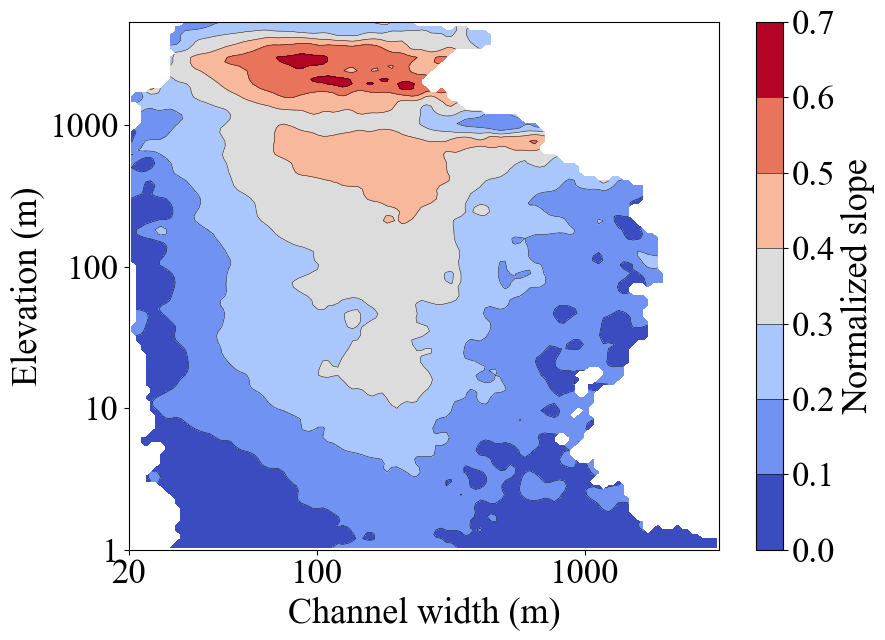

Band [0, 0.1]: 2724 grid cells (25.10% of supported cells; not contour area)
Band [0.1, 0.2]: 3824 grid cells (35.24% of supported cells; not contour area)
Band [0.2, 0.3]: 2800 grid cells (25.80% of supported cells; not contour area)
Band [0.3, 0.4]: 1141 grid cells (10.52% of supported cells; not contour area)
Band [0.4, 0.5]: 241 grid cells (2.22% of supported cells; not contour area)
Band [0.5, 0.6]: 121 grid cells (1.12% of supported cells; not contour area)
Band [0.6, 0.7]: 0 grid cells (0.00% of supported cells; not contour area)


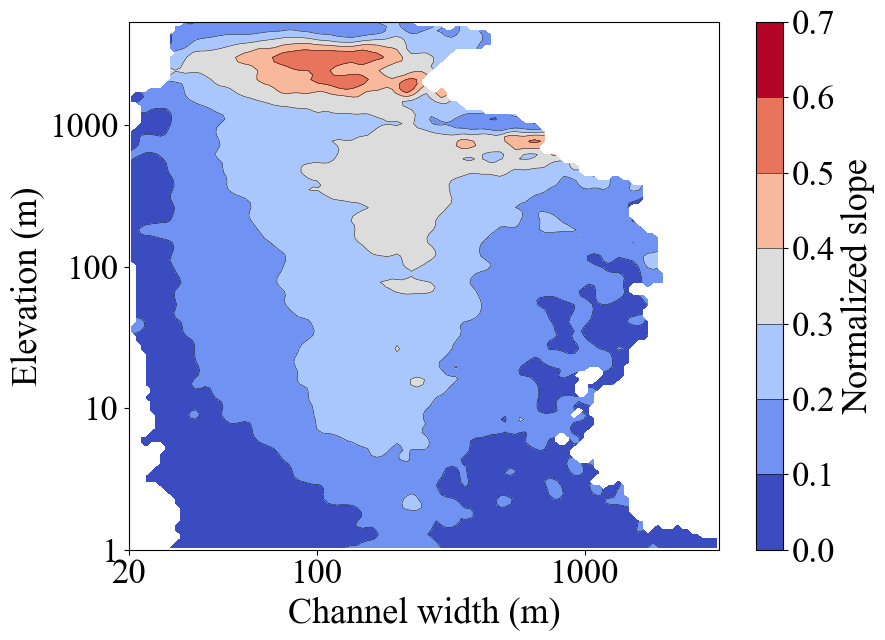


Variable: slope_out_normalized

Option 1: geometric centers
Level  0 [0.00, 0.10] | log center = (2.198, 0.723) | original center = (156.93, 4.28)
Level  1 [0.10, 0.20] | log center = (2.347, 1.337) | original center = (221.57, 20.71)
Level  2 [0.20, 0.30] | log center = (2.148, 1.969) | original center = (139.55, 92.18)
Level  3 [0.30, 0.40] | log center = (2.158, 2.391) | original center = (142.80, 245.29)
Level  4 [0.40, 0.50] | log center = (2.157, 2.965) | original center = (142.52, 920.73)
Level  5 [0.50, 0.60] | log center = (2.062, 3.390) | original center = (114.23, 2451.07)
Level  6 [0.60, 0.70] | log center = (2.056, 3.380) | original center = (112.64, 2399.81)

Option 3: density-peak centers
Level  0 [0.00, 0.10] | log peak = (1.658, 0.765) | original peak = (44.45, 4.82)
Level  1 [0.10, 0.20] | log peak = (1.658, 2.108) | original peak = (44.45, 127.16)
Level  2 [0.20, 0.30] | log peak = (1.658, 2.451) | original peak = (44.45, 281.63)
Level  3 [0.30, 0.40] | log peak = (

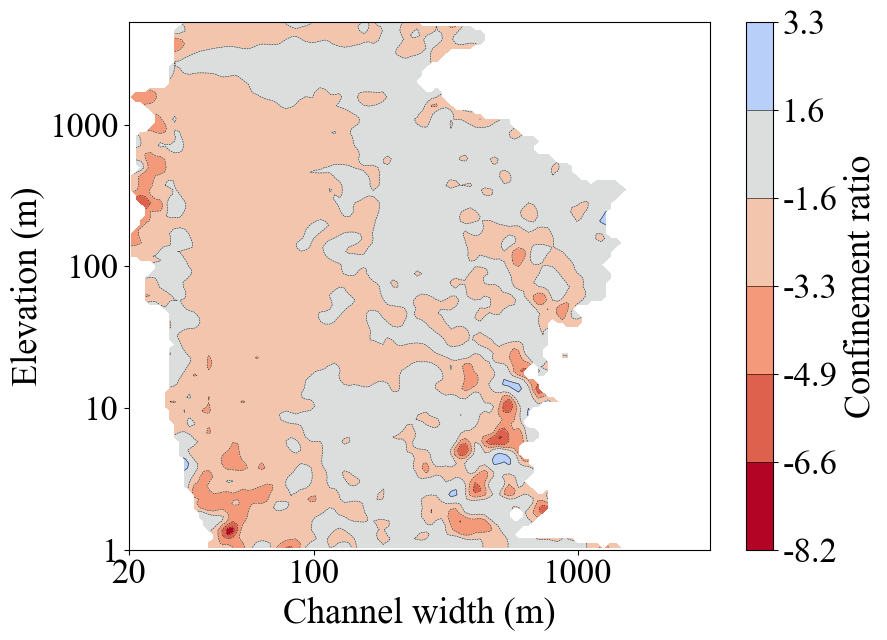


Variable: ER_diff

Option 1: geometric centers
Level  0 [-8.25, -6.60] | log center = (1.937, 0.296) | original center = (85.51, 0.98)
Level  1 [-6.60, -4.95] | log center = (2.289, 0.920) | original center = (193.55, 7.32)
Level  2 [-4.95, -3.30] | log center = (2.073, 1.137) | original center = (117.31, 12.70)
Level  3 [-3.30, -1.65] | log center = (1.987, 1.885) | original center = (96.00, 75.72)
Level  4 [-1.65, 1.65] | log center = (2.358, 1.902) | original center = (227.15, 78.83)
Level  5 [1.65, 3.30] | log center = (2.636, 1.007) | original center = (431.23, 9.17)

Option 3: density-peak centers
Level  0 [-8.25, -6.60] | log peak = (1.694, 0.140) | original peak = (48.45, 0.38)
Level  1 [-6.60, -4.95] | log peak = (1.914, 0.016) | original peak = (81.07, 0.04)
Level  2 [-4.95, -3.30] | log peak = (1.786, 1.356) | original peak = (60.07, 21.69)
Level  3 [-3.30, -1.65] | log peak = (1.658, 2.509) | original peak = (44.45, 321.98)
Level  4 [-1.65, 1.65] | log peak = (1.951, 2.166

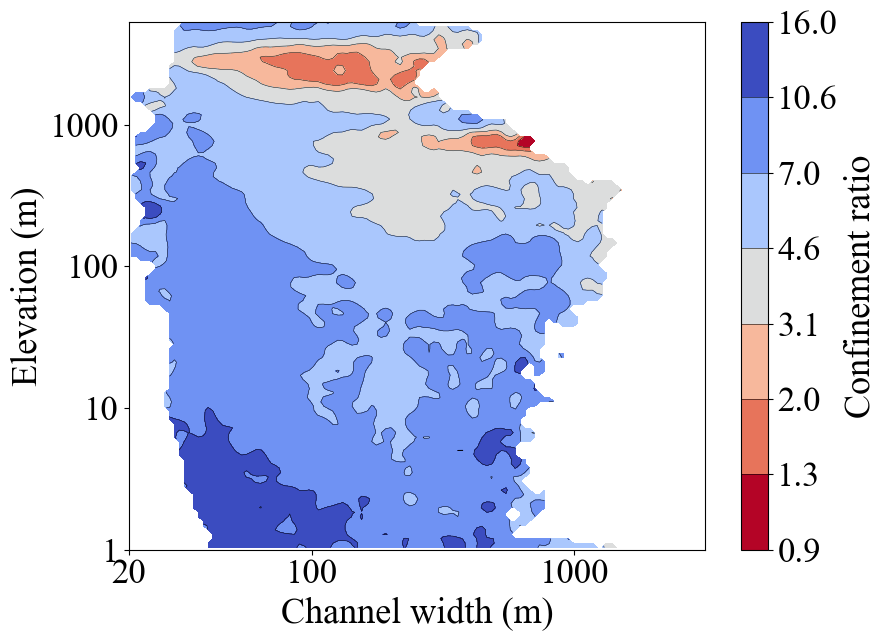


Variable: ER_diff_abs

Option 1: geometric centers
Level  0 [0.88, 1.33] | log center = (2.819, 2.880) | original center = (657.58, 757.14)
Level  1 [1.33, 2.02] | log center = (2.229, 3.238) | original center = (168.62, 1727.99)
Level  2 [2.02, 3.05] | log center = (2.203, 3.252) | original center = (158.59, 1784.78)
Level  3 [3.05, 4.61] | log center = (2.371, 2.818) | original center = (233.81, 657.14)
Level  4 [4.61, 6.98] | log center = (2.214, 2.201) | original center = (162.86, 157.94)
Level  5 [6.98, 10.56] | log center = (2.091, 1.325) | original center = (122.38, 20.15)
Level  6 [10.56, 15.97] | log center = (1.877, 0.440) | original center = (74.29, 1.76)

Option 3: density-peak centers
Level  0 [0.88, 1.33] | log peak = (2.812, 2.883) | original peak = (648.38, 763.21)
Level  1 [1.33, 2.02] | log peak = (1.804, 3.475) | original peak = (62.70, 2987.42)
Level  2 [2.02, 3.05] | log peak = (1.658, 3.475) | original peak = (44.45, 2987.42)
Level  3 [3.05, 4.61] | log peak = (1

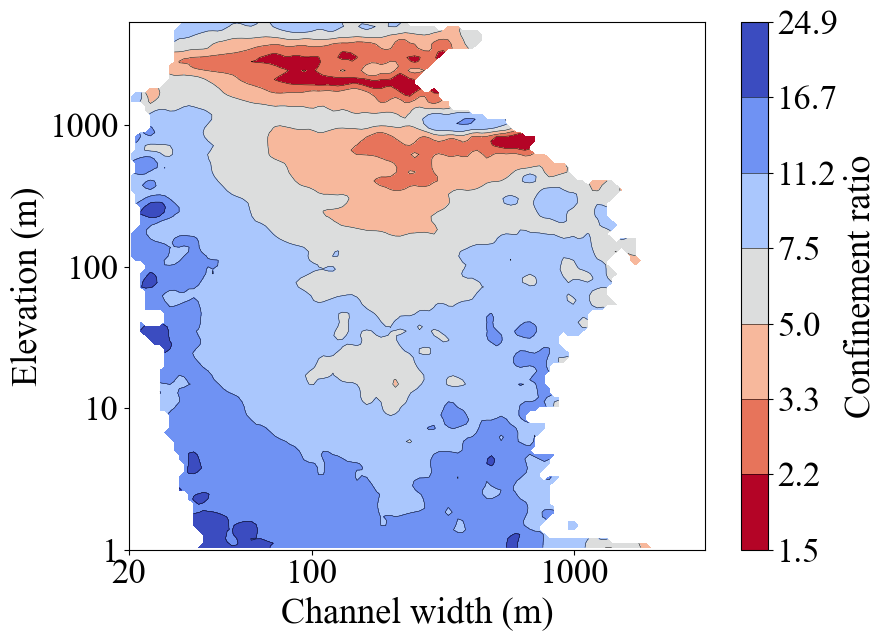

Band [1.49918, 2.23994]: 13 grid cells (0.13% of supported cells; not contour area)
Band [2.23994, 3.34672]: 212 grid cells (2.15% of supported cells; not contour area)
Band [3.34672, 5.00036]: 683 grid cells (6.94% of supported cells; not contour area)
Band [5.00036, 7.47107]: 1679 grid cells (17.06% of supported cells; not contour area)
Band [7.47107, 11.1626]: 3622 grid cells (36.81% of supported cells; not contour area)
Band [11.1626, 16.6781]: 3105 grid cells (31.55% of supported cells; not contour area)
Band [16.6781, 24.9189]: 526 grid cells (5.35% of supported cells; not contour area)


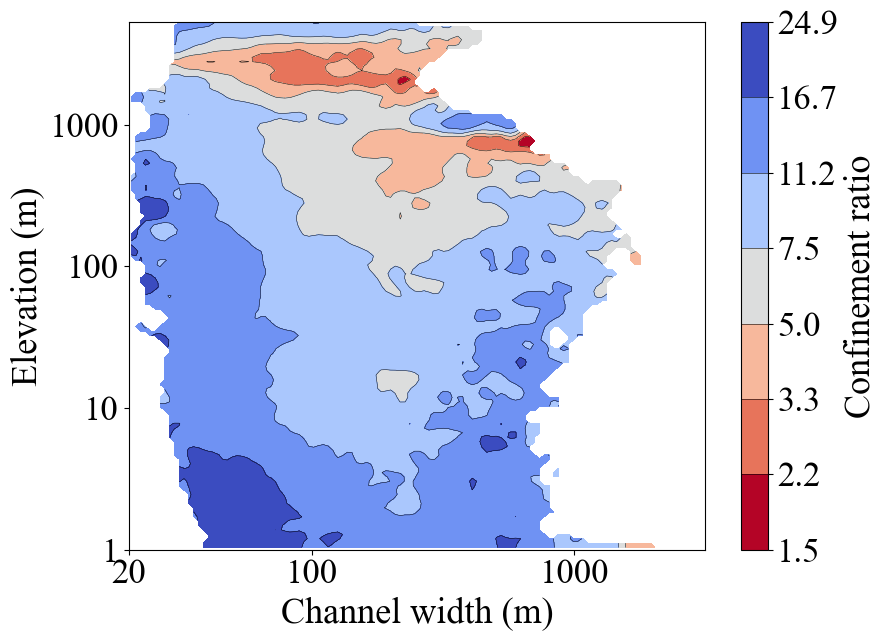


Variable: ER_out

Option 1: geometric centers
Level  0 [1.50, 2.24] | log center = (2.215, 3.285) | original center = (163.07, 1924.88)
Level  1 [2.24, 3.35] | log center = (2.195, 3.181) | original center = (155.72, 1516.78)
Level  2 [3.35, 5.00] | log center = (2.223, 2.861) | original center = (166.10, 724.37)
Level  3 [5.00, 7.47] | log center = (2.257, 2.335) | original center = (179.83, 215.17)
Level  4 [7.47, 11.16] | log center = (2.202, 1.619) | original center = (158.21, 40.55)
Level  5 [11.16, 16.68] | log center = (2.047, 0.752) | original center = (110.42, 4.65)
Level  6 [16.68, 24.92] | log center = (1.631, 0.688) | original center = (41.78, 3.87)

Option 3: density-peak centers
Level  0 [1.50, 2.24] | log peak = (1.768, 3.450) | original peak = (57.55, 2820.25)
Level  1 [2.24, 3.35] | log peak = (1.658, 3.482) | original peak = (44.45, 3030.57)
Level  2 [3.35, 5.00] | log peak = (1.841, 2.795) | original peak = (68.32, 622.31)
Level  3 [5.00, 7.47] | log peak = (1.658, 

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from scipy.ndimage import gaussian_filter

def create_contour_figures(dfP, vars_to_plot, cbar_label, level_step, saveN, use_log_levels, n_levels
                           ,base_cmap, titles, save_dir, center_zero=False):
    """Use center_zero for a neutral band spanning -level_step to level_step."""
    if center_zero and (use_log_levels or level_step <= 0):
        raise ValueError("center_zero requires linear levels and a positive level_step")
    
    save_names = [f"{save_dir}contour_WE{saveN}_{S}.png" for S in titles]
    
    [save_dir + f'contour_WE{saveN}_diff.png']
    
    nx, ny = 120, 120
    sigma = 1.2#1.2
    min_support = 2

    xmin_log = 1.3   # ~ 20 m
    xmax_log = 3.5   # ~ 3161 m


    dpi_save = 300

    # -------------------------
    # FONT SETTINGS
    # -------------------------
    font_family = 'Times New Roman'
    title_size = 18
    label_size = 26
    tick_size = 25
    cbar_label_size = 26
    cbar_tick_size = 25

    plt.rcParams['font.family'] = font_family
    plt.rcParams['axes.titlesize'] = title_size
    plt.rcParams['axes.labelsize'] = label_size
    plt.rcParams['xtick.labelsize'] = tick_size
    plt.rcParams['ytick.labelsize'] = tick_size

    # =========================================================
    # FIRST PASS: COMPUTE BOTH SMOOTHED FIELDS
    # =========================================================
    plot_data = {}

    for c in vars_to_plot:
        x = dfP["bendWidths"].to_numpy()
        y = dfP["bendHeight"].to_numpy()
        z = dfP[c].to_numpy()
        raw_finite = z[np.isfinite(z)]
        print(f"\n{c}: raw finite values: n={raw_finite.size}, "
              f"range=[{raw_finite.min():.6g}, {raw_finite.max():.6g}], "
              f"outside +/-2={np.count_nonzero(np.abs(raw_finite) > 2)}")

        mask = (
            np.isfinite(x) &
            np.isfinite(y) &
            np.isfinite(z) &
            (x >= 0) &
            (y >= 0)
        )

        x = x[mask]
        y = y[mask]
        z = z[mask]

        x_plot = np.log10(x + 1)
        y_plot = np.log10(y + 1)

        mask_xy = (x_plot >= xmin_log) & (x_plot <= xmax_log)
        x_plot = x_plot[mask_xy]
        y_plot = y_plot[mask_xy]
        z = z[mask_xy]
        print(f"After coordinate/width filtering: n={z.size}, "
              f"range=[{z.min():.6g}, {z.max():.6g}], "
              f"outside +/-2={np.count_nonzero(np.abs(z) > 2)}")

        xedges = np.linspace(xmin_log, xmax_log, nx + 1)
        yedges = np.linspace(np.nanmin(y_plot), np.nanmax(y_plot), ny + 1)

        sum_z, _, _ = np.histogram2d(x_plot, y_plot, bins=[xedges, yedges], weights=z)
        count, _, _ = np.histogram2d(x_plot, y_plot, bins=[xedges, yedges])

        sum_z_s = gaussian_filter(sum_z, sigma=sigma)
        count_s = gaussian_filter(count.astype(float), sigma=sigma)

        Zsmooth = np.divide(
            sum_z_s,
            count_s,
            out=np.full_like(sum_z_s, np.nan),
            where=count_s > 0
        )

        finite_smooth = Zsmooth[np.isfinite(Zsmooth)]
        print(f"Smoothed averages before support mask: "
              f"range=[{finite_smooth.min():.6g}, {finite_smooth.max():.6g}]")
        Zsmooth[count_s < min_support] = np.nan
        supported = Zsmooth[np.isfinite(Zsmooth)]
        if supported.size == 0:
            raise ValueError(f"{c}: no grid cells meet min_support={min_support}")
        print(f"Smoothed averages after support mask: n={supported.size} cells, "
              f"range=[{supported.min():.6g}, {supported.max():.6g}]")

        xc = 0.5 * (xedges[:-1] + xedges[1:])
        yc = 0.5 * (yedges[:-1] + yedges[1:])
        X, Y = np.meshgrid(xc, yc, indexing="ij")

        plot_data[c] = {
            "X": X,
            "Y": Y,
            "Zsmooth": Zsmooth,
            "count_s": count_s
        }

    # =========================================================
    # SHARED OBSERVED LEVELS ACROSS BOTH FIELDS
    # =========================================================
    all_z = np.concatenate([
        plot_data[c]["Zsmooth"][np.isfinite(plot_data[c]["Zsmooth"])]
        for c in vars_to_plot
    ])


    shared_min = np.nanmin(all_z)
    shared_max = np.nanmax(all_z)

    if center_zero:
        # Assign colors on a symmetric scale, then trim unused outer bands.
        n_steps = max(1, int(np.ceil(np.max(np.abs(all_z)) / level_step)))
        positive_levels = level_step * np.arange(1, n_steps + 1)
        full_levels = np.concatenate((-positive_levels[::-1], positive_levels))
        full_n_bands = len(full_levels) - 1
        full_color_positions = (
            np.linspace(0, 1, full_n_bands)
            if full_n_bands > 1 else np.array([0.5])
        )
        first_band = np.clip(
            np.searchsorted(full_levels, shared_min, side='right') - 1,
            0, full_n_bands - 1
        )
        last_band = np.clip(
            np.searchsorted(full_levels, shared_max, side='left') - 1,
            first_band, full_n_bands - 1
        )
        # Always retain the complete neutral band around zero.
        center_band = n_steps - 1
        first_band = min(first_band, center_band)
        last_band = max(last_band, center_band)
        levels = full_levels[first_band:last_band + 2]
        color_positions = full_color_positions[first_band:last_band + 1]
    elif use_log_levels:
        # geomspace requires strictly positive values
        shared_min = max(shared_min, 1e-3)
        levels = np.geomspace(shared_min, shared_max, n_levels)
    else:
        shared_min = np.floor(shared_min / level_step) * level_step
        shared_max = np.ceil(shared_max / level_step) * level_step

        if shared_min == shared_max:
            shared_min -= level_step
            shared_max += level_step

        levels = np.arange(shared_min, shared_max + level_step / 2, level_step)

    print("Shared contour/colorbar levels:")
    print(levels)

    # =========================================================
    # DISCRETE COLORMAP
    # =========================================================
    n_bands = len(levels) - 1
    if not center_zero:
        color_positions = np.linspace(0, 1, n_bands) if n_bands > 1 else np.array([0.5])
    colors = base_cmap(color_positions)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

    # =========================================================
    # PLOTTING: TWO SEPARATE FIGURES
    # =========================================================
    all_centers = {}

    for i, c in enumerate(vars_to_plot):
        X = plot_data[c]["X"]
        Y = plot_data[c]["Y"]
        Zsmooth = plot_data[c]["Zsmooth"]
        count_s = plot_data[c]["count_s"]

        fig, ax = plt.subplots(figsize=(9, 6.5))

        # filled contours
        cf = ax.contourf(
            X, Y, Zsmooth,
            levels=levels,
            cmap=cmap,
            norm=norm,
            extend='neither'
        )

        # contour lines
        ax.contour(
            X, Y, Zsmooth,
            levels=levels,
            colors='k',
            linewidths=0.35
        )

        # -------------------------
        # compute centers
        # -------------------------
        option1_centers = []
        option3_centers = []

        for j in range(len(levels) - 1):
            low = levels[j]
            high = levels[j + 1]

            if j == len(levels) - 2:
                band_mask = (
                    np.isfinite(Zsmooth) &
                    (Zsmooth >= low) &
                    (Zsmooth <= high)
                )
            else:
                band_mask = (
                    np.isfinite(Zsmooth) &
                    (Zsmooth >= low) &
                    (Zsmooth < high)
                )

            band_count = np.count_nonzero(band_mask)
            print(f"Band [{low:.6g}, {high:.6g}]: {band_count} grid cells "
                  f"({100 * band_count / np.count_nonzero(np.isfinite(Zsmooth)):.2f}% "
                  "of supported cells; not contour area)")
            if not np.any(band_mask):
                continue

            # Option 1: geometric center
            x_center_log = np.nanmean(X[band_mask])
            y_center_log = np.nanmean(Y[band_mask])

            x_center_orig = 10**x_center_log - 1
            y_center_orig = 10**y_center_log - 1

            option1_centers.append({
                "level_index": j,
                "level_low": low,
                "level_high": high,
                "x_log": x_center_log,
                "y_log": y_center_log,
                "x_orig": x_center_orig,
                "y_orig": y_center_orig
            })

            # ax.scatter(
            #     x_center_log, y_center_log,
            #     s=45, c='black', marker='o',
            #     edgecolor='white', linewidth=0.6, zorder=10
            # )

            # Option 3: highest density cell inside the level band
            density_in_band = np.where(band_mask, count_s, np.nan)

            if not np.all(np.isnan(density_in_band)):
                peak_idx = np.nanargmax(density_in_band)
                ix, iy = np.unravel_index(peak_idx, density_in_band.shape)

                x_peak_log = X[ix, iy]
                y_peak_log = Y[ix, iy]

                x_peak_orig = 10**x_peak_log - 1
                y_peak_orig = 10**y_peak_log - 1

                option3_centers.append({
                    "level_index": j,
                    "level_low": low,
                    "level_high": high,
                    "x_log": x_peak_log,
                    "y_log": y_peak_log,
                    "x_orig": x_peak_orig,
                    "y_orig": y_peak_orig
                })

                # ax.scatter(
                #     x_peak_log, y_peak_log,
                #     s=55, c='yellow', marker='X',
                #     edgecolor='black', linewidth=0.6, zorder=11
                # )

        all_centers[c] = {
            "option1_geometric_center": option1_centers,
            "option3_density_peak": option3_centers
        }

        # -------------------------
        # colorbar
        # -------------------------
        cbar = fig.colorbar(
            cf,
            ax=ax,
            boundaries=levels,
            ticks=levels,
            spacing='uniform',
            drawedges=True
        )
        cbar.set_ticklabels([f"{lv:.1f}" for lv in levels])
        cbar.set_label(cbar_label, fontsize=cbar_label_size, fontname=font_family)
        cbar.ax.tick_params(labelsize=cbar_tick_size)

        # force Times New Roman on colorbar tick labels
        for ticklab in cbar.ax.get_yticklabels():
            ticklab.set_fontname(font_family)

        # -------------------------
        # axis formatting
        # -------------------------
        ax.set_xlim(xmin_log, xmax_log)

        xticks_log = np.array([1.3, 2, 3])
        xtick_labels = ['20', '100', '1000']
        ax.set_xticks(xticks_log)
        ax.set_xticklabels(xtick_labels, fontname=font_family)

        yticks_log = np.array([0, 1, 2, 3])
        ytick_labels = ['1', '10', '100', '1000']
        ax.set_yticks(yticks_log)
        ax.set_yticklabels(ytick_labels, fontname=font_family)

        ax.set_xlabel("Channel width (m)", fontsize=label_size, fontname=font_family)
        ax.set_ylabel("Elevation (m)", fontsize=label_size, fontname=font_family)
        # ax.set_title(titles[i], fontsize=title_size, fontname=font_family)

        ax.tick_params(axis='both', which='major', labelsize=tick_size)

        plt.tight_layout()
        plt.savefig(save_names[i], dpi=dpi_save, bbox_inches='tight')
        plt.show()

    # =========================================================
    # PRINT CENTERS
    # =========================================================
    for var_name, result in all_centers.items():
        print(f"\n{'='*80}")
        print(f"Variable: {var_name}")
        print(f"{'='*80}")

        print("\nOption 1: geometric centers")
        for item in result["option1_geometric_center"]:
            print(
                f"Level {item['level_index']:2d} "
                f"[{item['level_low']:.2f}, {item['level_high']:.2f}] | "
                f"log center = ({item['x_log']:.3f}, {item['y_log']:.3f}) | "
                f"original center = ({item['x_orig']:.2f}, {item['y_orig']:.2f})"
            )

        print("\nOption 3: density-peak centers")
        for item in result["option3_density_peak"]:
            print(
                f"Level {item['level_index']:2d} "
                f"[{item['level_low']:.2f}, {item['level_high']:.2f}] | "
                f"log peak = ({item['x_log']:.3f}, {item['y_log']:.3f}) | "
                f"original peak = ({item['x_orig']:.2f}, {item['y_orig']:.2f})"
            )


# =========================================================
# SETTINGS
# =========================================================
dfP = dfCluster.copy()
save_dir = str(figures_dir) + os.sep

# Slope runs difference
dfP['slope_diff_normalized']     = dfP['slope_out_normalized'] - dfP['slope_inn_normalized']
dfP['slope_diff_abs_normalized'] = abs(dfP['slope_out_normalized'] - dfP['slope_inn_normalized'])

create_contour_figures(dfP, ['slope_diff_normalized'], "Normalized slope", 0.05, 'S', False, 6
                           ,plt.cm.coolwarm,  ['diff'], save_dir, center_zero=True)
create_contour_figures(dfP, ['slope_diff_abs_normalized'], "Normalized slope", 0.05, 'S', False, 8
                           ,plt.cm.coolwarm,  ['diff_abs'], save_dir)

create_contour_figures(dfP, ['slope_out_normalized', 'slope_inn_normalized'], "Normalized slope", 0.1, 'S', False, 8
                           ,plt.cm.coolwarm,  ['out', 'inn'], save_dir)


# ER difference
dfP['ER_diff_abs'] = abs(dfP['ER_out'] - dfP['ER_inn'])
dfP['ER_diff']     = dfP['ER_out'] - dfP['ER_inn']

create_contour_figures(dfP, ['ER_diff'], "Confinement ratio", 1.65, 'E', False, 8
                           ,plt.cm.coolwarm_r,  ['diff'], save_dir, center_zero=True)
create_contour_figures(dfP, ['ER_diff_abs'], "Confinement ratio", 0.1, 'E', True, 8
                           ,plt.cm.coolwarm_r,  ['diff_abs'], save_dir)


create_contour_figures(dfP, ['ER_out', 'ER_inn'], "Confinement ratio", 0.1, 'E', True, 8
                           ,plt.cm.coolwarm_r,  ['out', 'inn'], save_dir)



## Distribution

In [44]:
import seaborn as sns

In [45]:
dfCluster['ER_out_log'] = np.log10(dfCluster['ER_out'])
dfCluster['ER_inn_log'] = np.log10(dfCluster['ER_inn'])

dfCluster['slope_out_normalized_log'] = np.log10(dfCluster['slope_out_normalized'])
dfCluster['slope_inn_normalized_log'] = np.log10(dfCluster['slope_inn_normalized'])

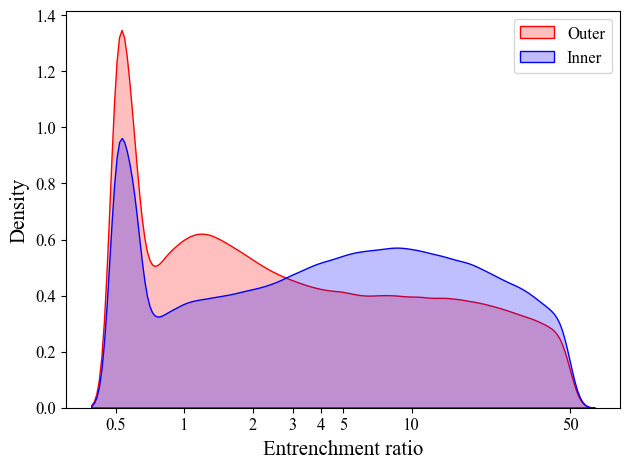

In [46]:
labelsize = 15
tickSize = 12
f,ax = plt.subplots()
sns.kdeplot(data = dfCluster,x = 'ER_out_log', fill=True, ax = ax, color = 'red' , label = 'Outer')
sns.kdeplot(data = dfCluster,x = 'ER_inn_log', fill=True, ax = ax, color = 'blue', label = 'Inner')
ax.set_xlabel('Entrenchment ratio', fontsize = labelsize)
ax.set_ylabel('Density', fontsize = labelsize)
ax.tick_params(axis = 'both', which = 'major', labelsize = tickSize)

plt.legend(title_fontsize = 12, fontsize = 12)
ax.set_xticks([-0.301 ,0.0 ,0.301 ,0.477 ,0.602 ,0.699 ,1.0, 1.699], [0.5,1,2,3,4,5,10, 50])
# plt.xlim([-3.5, 0])
plt.tight_layout()
plt.savefig(save_dir + 'norm_slope_inOut_02_KDE.png', dpi = 1000)
plt.show()

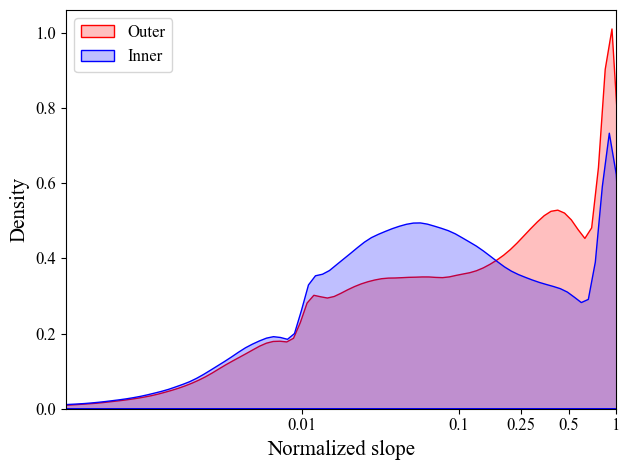

In [47]:
labelsize = 15
tickSize = 12
f,ax = plt.subplots()
sns.kdeplot(data = dfCluster,x = 'slope_out_normalized_log', fill=True, ax = ax, color = 'red' , label = 'Outer')
sns.kdeplot(data = dfCluster,x = 'slope_inn_normalized_log', fill=True, ax = ax, color = 'blue', label = 'Inner')
ax.set_xlabel('Normalized slope', fontsize = labelsize)
ax.set_ylabel('Density', fontsize = labelsize)
ax.tick_params(axis = 'both', which = 'major', labelsize = tickSize)

plt.legend(title_fontsize = 12, fontsize = 12)
ax.set_xticks([0.0 ,-2, -1,-0.602, -0.301], [1,0.01, 0.1, 0.25, 0.5])
plt.xlim([-3.5, 0])
plt.tight_layout()
plt.savefig(save_dir + 'norm_slope_inOut_02_KDE.png', dpi = 1000)
plt.show()

## Confinement profiles

In [48]:
from scipy.stats import gaussian_kde
import pickle
from matplotlib.patches import Patch

labelsize = 15
tickSize = 12

In [49]:
clusters = 7
dfCluster = applyGMM(dfCluster, ['PCA1', 'PCA2', 'PCA3'], clusters, 'kmeans', 100, 'tied', 5)


In [50]:
cols_of_interest = [col for col in dfCluster.columns if col.startswith(f"GMM_{clusters}_") and col.endswith("_soft")]
for thres in [0.9,0.95,0.99]:
    dfCluster.loc[dfCluster[cols_of_interest].max(axis=1) >= thres, f'GMM_{clusters}_{int(thres*100)}'] = dfCluster[f'GMM_{clusters}_hard']


In [51]:
def apply_kde(df, cluster, maxCluster, comb, res=80, det_tol=1e-12,
              max_points=6000, eval_batch=1000, random_state=42):
    d = df.loc[df[f'GMM_{maxCluster}_hard'] == cluster, comb].copy()
    d = d.apply(pd.to_numeric, errors='coerce')
    d = d[np.isfinite(d).all(axis=1)]

    if len(d) < 3:
        print(f'Not enough finite points for {comb}: cluster {cluster}')
        return None

    if len(d) > max_points:
        d = d.sample(n=max_points, random_state=random_state)

    x = d[comb[0]].to_numpy(dtype=float)
    y = d[comb[1]].to_numpy(dtype=float)
    data = np.vstack([x, y])

    cov = np.cov(data)
    det = np.linalg.det(cov)

    if (not np.isfinite(cov).all()) or (det <= det_tol):
        print(f'Singular / near-singular covariance for {comb}: cluster {cluster}')
        return None

    kde = gaussian_kde(data)

    xmin, xmax = x.min() - 1, x.max() + 1
    ymin, ymax = y.min() - 1, y.max() + 1
    X, Y = np.meshgrid(np.linspace(xmin, xmax, res, dtype=np.float32),
                       np.linspace(ymin, ymax, res, dtype=np.float32))
    positions = np.vstack([X.ravel(), Y.ravel()]).astype(float)
    z_chunks = []
    for start in range(0, positions.shape[1], eval_batch):
        z_chunks.append(kde(positions[:, start:start + eval_batch]))
    Z = np.concatenate(z_chunks).reshape(X.shape).astype(np.float32)
    return X, Y, Z




In [52]:
def apply_kde_to_cluster(dfC, combs):
    

    combNames = ['KDE_slopeOut_vs_slopeLeft', 'KDE_slopeInn_vs_slopeLeft']
    clusters = 7
    kde_list = []
    for comb in combs:
        print(combs)
        k = []
        for c in tqdm(range(clusters)):
        # for c in [1]:
            k.append(apply_kde(dfC, c, clusters, comb, res=400, max_points=20000, eval_batch=1000))
        kde_list.append(k)
    return kde_list
combs = [['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized']]
kde_list = apply_kde_to_cluster(dfCluster, combs)
dfCluster90 = dfCluster.copy()
dfCluster90 = dfCluster90[~dfCluster90['GMM_7_90'].isna()]
kde_list90 = apply_kde_to_cluster(dfCluster90, combs)
dfCluster95 = dfCluster.copy()
dfCluster95 = dfCluster95[~dfCluster95['GMM_7_95'].isna()]
kde_list95 = apply_kde_to_cluster(dfCluster95, combs)


[['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized']]


  0%|          | 0/7 [00:00<?, ?it/s]

Singular / near-singular covariance for ['slope_out_normalized', 'slope_left_normalized']: cluster 0


 71%|███████▏  | 5/7 [00:32<00:14,  7.27s/it]

Singular / near-singular covariance for ['slope_out_normalized', 'slope_left_normalized']: cluster 5


...

 29%|██▊       | 2/7 [00:16<00:39,  7.92s/it]

Singular / near-singular covariance for ['slope_inn_normalized', 'slope_left_normalized']: cluster 2


 57%|█████▋    | 4/7 [00:24<00:16,  5.56s/it]

Singular / near-singular covariance for ['slope_inn_normalized', 'slope_left_normalized']: cluster 4


100%|██████████| 7/7 [00:40<00:00,  5.85s/it]


['slope_out_normalized', 'slope_left_normalized']
['slope_inn_normalized', 'slope_left_normalized']


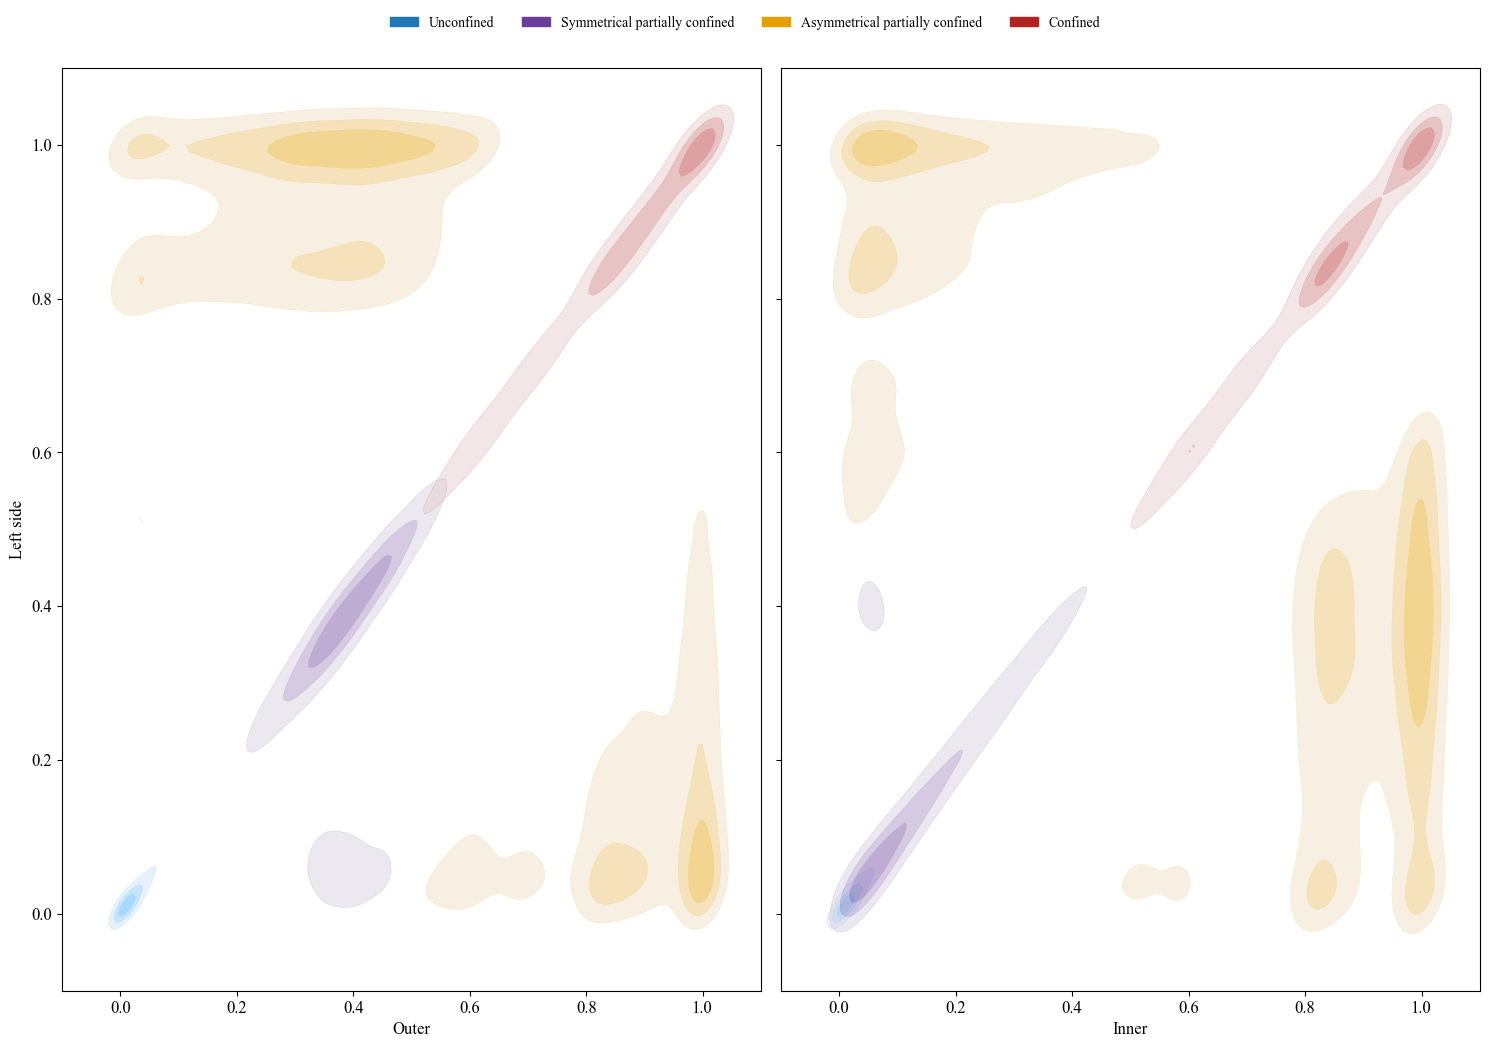

90
['slope_out_normalized', 'slope_left_normalized']
['slope_inn_normalized', 'slope_left_normalized']


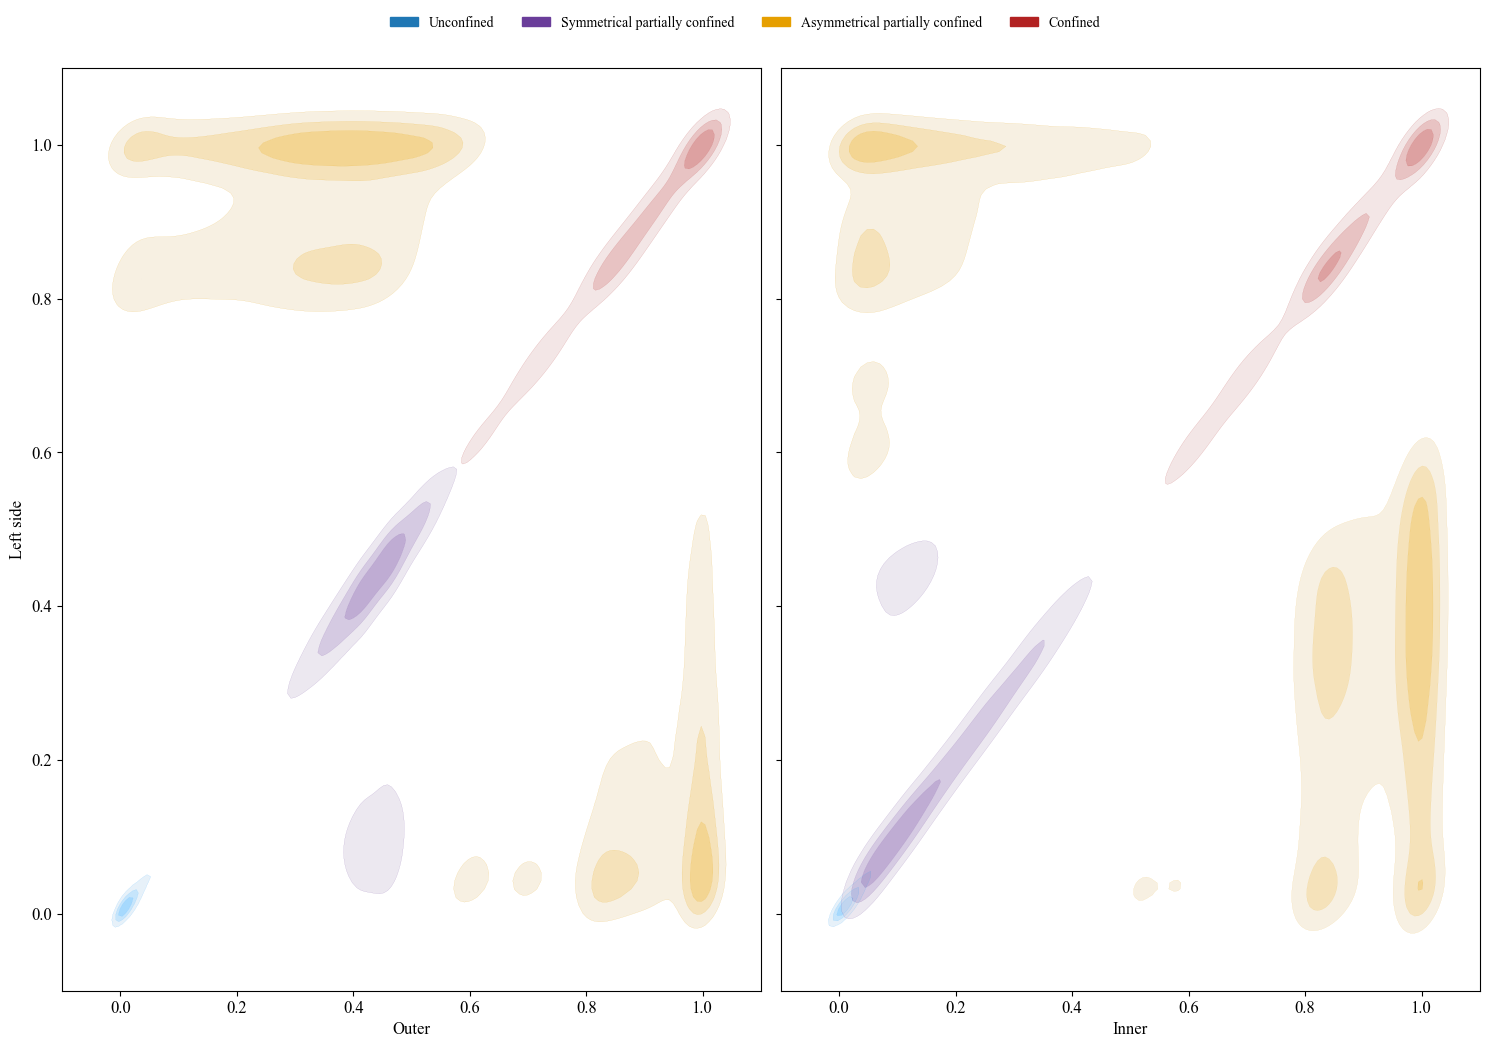

95
['slope_out_normalized', 'slope_left_normalized']
['slope_inn_normalized', 'slope_left_normalized']


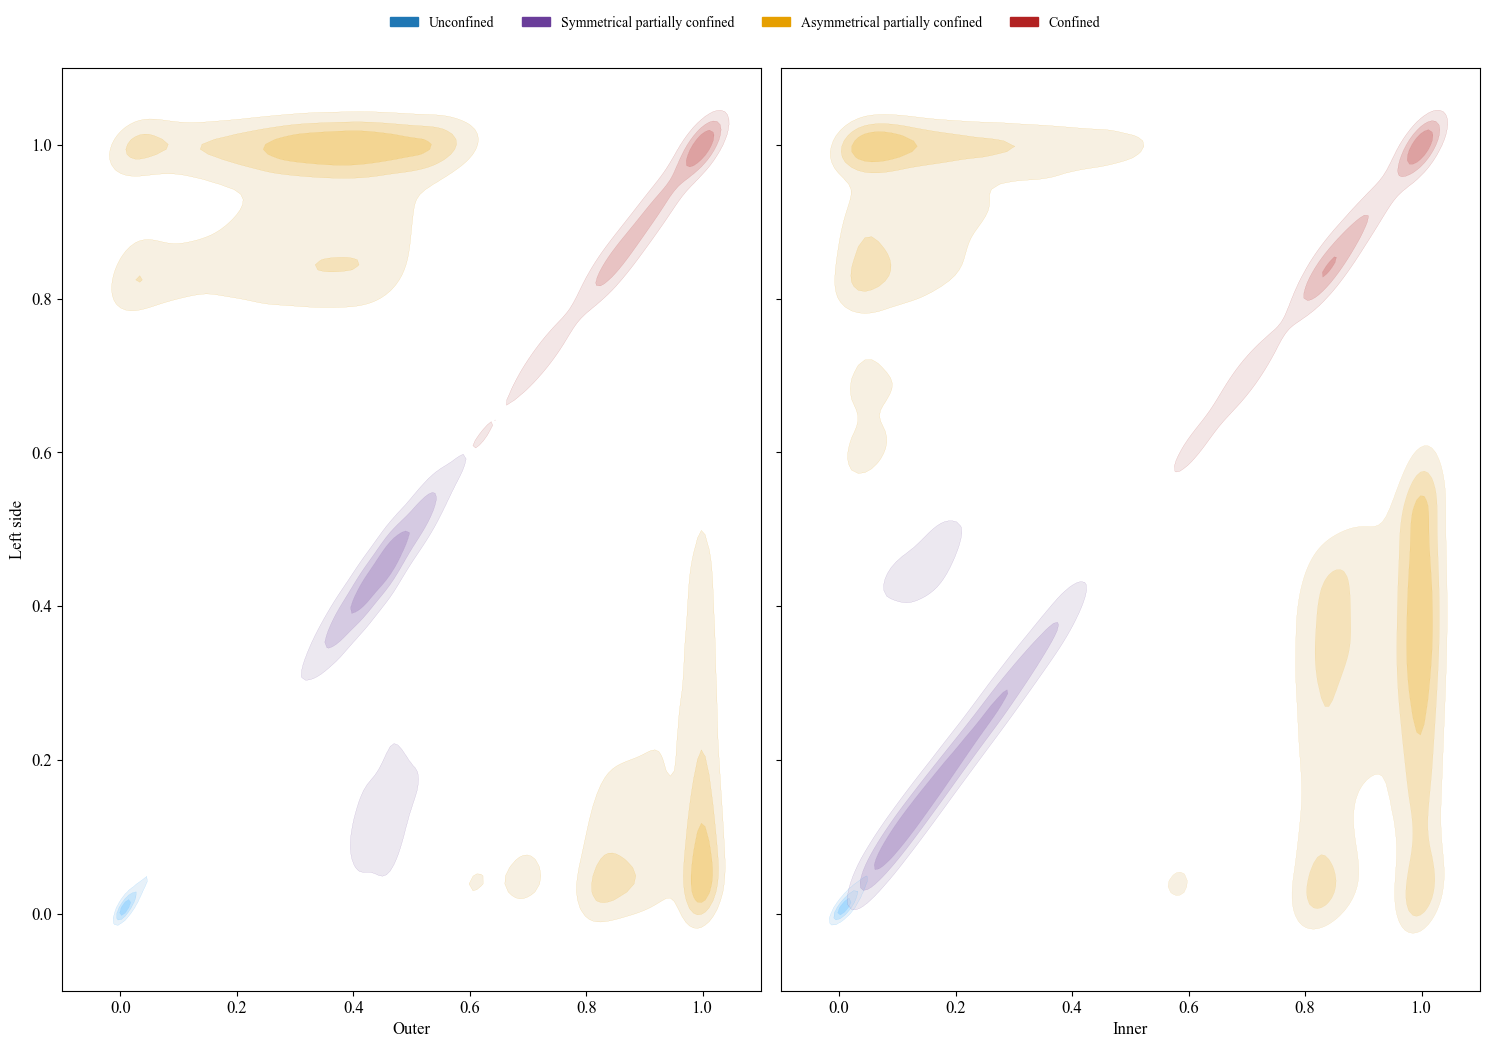

In [59]:

def plot_kde_clusters(kde_list, combs, clusters, percentage = 100):

    colors = ["#e69f00", "#2fa8ff", '#e69f00', '#6a3d9a', '#e69f00', '#e69f00',  "#b22222"]
    # colors = ['#1F4E79', '#2A9D8F',  '#8B2C2C','#E69F00', "#7B6ED6",'#4D4D4D', '#E6D3A3']
    # Unconfined: 1 
    # Partial symmetrical:  3
    # Partial asymmetrical: 0-2-4-5
    # Unconfined:6

    xlab = ['Outer', 'Inner', 'Outer', 'Inner']
    f,ax = plt.subplots(ncols = 2, nrows = 1, figsize = [15,10], squeeze = False, sharey = True)
    ax = ax.flatten()
    for i, comb in enumerate(combs[0:2]):
        print(comb)
        for c in range(clusters):
            if kde_list[i][c] is not None:
                X, Y, Z = kde_list[i][c]

                ZRel = Z/Z.max()
                Z    = np.where(ZRel < 0.001, np.nan, ZRel)

                # Define contour levels ABOVE min_density
                Z_min = np.nanmin(Z)
                Z_max = np.nanmax(Z)
                n_levels = 4
                levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density
                levels = np.array([0.001, 0.25, 0.5, 0.75, 1.0])
                if all(levels == 0):
                    continue
                # print(c, levels)
                # Filled contours (shades of one color)
                cmap = sns.light_palette(colors[c], as_cmap=True)
                if c == 0:
                    zz = 1000
                else:
                    zz = 1
                cf  = ax[i].contourf(X, Y, Z, levels=levels[1:], cmap=cmap, alpha = 0.5, antialiased = True, zorder = zz)

                
                ax[i].set_xlim([-0.1,1.1])
                ax[i].set_ylim([-0.1,1.1])
                ax[i].set_xlabel(xlab[i], fontsize = 12)
                ax[i].tick_params(axis='both', which='major', labelsize=tickSize)

                cs = ax[i].contour(X, Y, Z, levels=levels[0:], colors=colors[c], linewidths=0.07)

    # Create legend handles manually (to ensure one instance of each label)

    legendColors = colors
    legendLabels = list(np.arange(len(colors)))
    handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

    legendColors = colors = ['#1f77b4','#6a3d9a', "#e69f00", "#b22222"]
    legendLabels = ['Unconfined','Symmetrical partially confined', 'Asymmetrical partially confined' , 'Confined']
    handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

    # Add shared legend at the top center
    lgd = f.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.05),
        ncol=8,
        frameon=False,
        title_fontsize = 12
    )
    ax[0].set_ylabel('Left side', fontsize = 12)


    plt.tight_layout()
    if percentage == 100:
        name = f'KDE_confinement_clustering_{clusters}_4.svg'
    else:
        name = f'KDE_confinement_clustering_{clusters}_4_{percentage}.png'
    plt.savefig(save_dir + name, bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 2000)
    plt.show()

plot_kde_clusters(kde_list, combs, clusters)
print(90)
plot_kde_clusters(kde_list90, combs, clusters, percentage=90)
print(95)
plot_kde_clusters(kde_list95, combs, clusters, percentage=95)

# Appendix

In [60]:
clusters = 7
dfCluster = applyGMM(dfCluster, ['PCA1', 'PCA2', 'PCA3'], clusters, 'kmeans', 100, 'tied', 5)



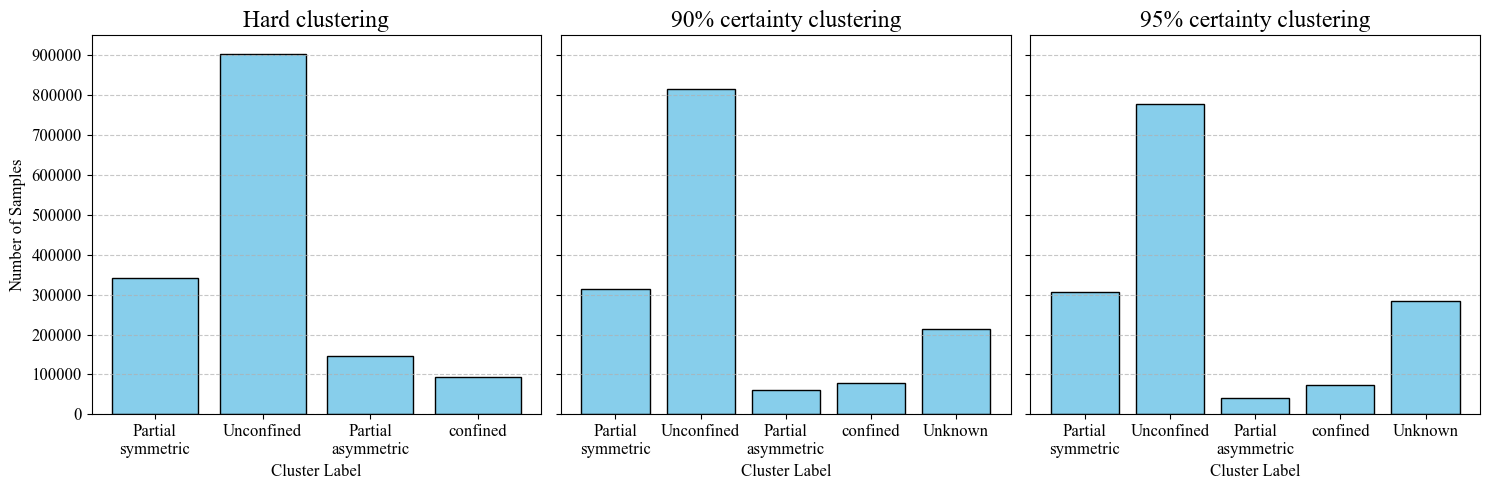

In [ ]:
def plot_histograms(dfC):
    dfCluster = dfC.copy()
    cols_of_interest = [col for col in dfCluster.columns if col.startswith(f"GMM_{clusters}_") and col.endswith("_soft")]
    for thres in [0.9,0.95,0.99]:
        dfCluster.loc[dfCluster[cols_of_interest].max(axis=1) >= thres, f'GMM_{clusters}_{int(thres*100)}'] = dfCluster[f'GMM_{clusters}_hard']

    i = 0
    levels = ['hard', '90', '95']
    f,ax =plt.subplots(ncols = len(levels), nrows = 1, squeeze = False, figsize = [15,5], sharey =True)

    titles = ['Hard clustering', '90% certainty clustering', '95% certainty clustering', '99% certainty clustering']
    for i in range(len(levels)):
        labels = dfCluster[f'GMM_{clusters}_{levels[i]}']
        labels[labels == 2] = 0
        labels[labels == 4] = 0
        labels[labels == 5] = 0
        unique_labels, counts = np.unique(labels, return_counts=True)
        
        # Optional: sort clusters by label
        sorted_indices = np.argsort(unique_labels)
        unique_labels = unique_labels[sorted_indices]
        counts = counts[sorted_indices]

        if levels[i] == 'hard':
            unique_labels = [ 'Partial\nsymmetric','Unconfined', 'Partial\nasymmetric', 'confined']
        else:
            unique_labels = [ 'Partial\nsymmetric','Unconfined', 'Partial\nasymmetric', 'confined', 'Unknown']
        ax[0,i].bar([str(lbl) for lbl in unique_labels], counts, color='skyblue', edgecolor='black')
        ax[0,i].set_yticks(np.arange(0, 1.2e6, 1e5))
        ax[0,i].set_xlabel("Cluster Label", fontsize = 12)
        ax[0,i].tick_params(axis='x', labelsize=12)
        ax[0,i].tick_params(axis='y', labelsize=12)
        
        ax[0,i].set_title(titles[i], fontsize = 17)
        ax[0,i].grid(axis='y', linestyle='--', alpha=0.7)
        ax[0,i].set_ylim(0,950000)
    ax[0,0].set_ylabel("Number of Samples", fontsize = 12)
    plt.tight_layout()
    plt.savefig(save_dir + 'GMM_7_hist.png')
    plt.show()
plot_histograms(dfCluster)

## Cluster distribution

In [67]:
def apply_kde(df, cluster, maxCluster, comb, res=80, det_tol=1e-12,
              max_points=5000, eval_batch=1000, random_state=42):
    d = df.loc[df[f'GMM_{maxCluster}_hard'] == cluster, comb].copy()
    d = d.apply(pd.to_numeric, errors='coerce')
    d = d[np.isfinite(d).all(axis=1)]

    if len(d) < 3:
        print(f'Not enough finite points for {comb}: cluster {cluster}')
        return None

    if len(d) > max_points:
        d = d.sample(n=max_points, random_state=random_state)

    x = d[comb[0]].to_numpy(dtype=float)
    y = d[comb[1]].to_numpy(dtype=float)
    data = np.vstack([x, y])

    cov = np.cov(data)
    det = np.linalg.det(cov)

    if (not np.isfinite(cov).all()) or (det <= det_tol):
        print(f'Singular / near-singular covariance for {comb}: cluster {cluster}')
        return None

    kde = gaussian_kde(data)

    xmin, xmax = x.min() - 1, x.max() + 1
    ymin, ymax = y.min() - 1, y.max() + 1
    X, Y = np.meshgrid(np.linspace(xmin, xmax, res, dtype=np.float32),
                       np.linspace(ymin, ymax, res, dtype=np.float32))
    positions = np.vstack([X.ravel(), Y.ravel()]).astype(float)
    z_chunks = []
    for start in range(0, positions.shape[1], eval_batch):
        z_chunks.append(kde(positions[:, start:start + eval_batch]))
    Z = np.concatenate(z_chunks).reshape(X.shape).astype(np.float32)
    return X, Y, Z

combs = [['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized'],
         ['slope_out_normalized', 'slope_right_normalized'], ['slope_inn_normalized', 'slope_right_normalized']]
combNames = ['KDE_slopeOut_vs_slopeLeft', 'KDE_slopeInn_vs_slopeLeft']
clusters = 7
kde_list = []
for comb in combs:
    print(combs)
    k = []
    for c in tqdm(range(clusters)):
    # for c in [1]:
        k.append(apply_kde(dfCluster, c, clusters, comb, res=100, max_points=20000, eval_batch=1000))
    kde_list.append(k)



[['slope_out_normalized', 'slope_left_normalized'], ['slope_inn_normalized', 'slope_left_normalized'], ['slope_out_normalized', 'slope_right_normalized'], ['slope_inn_normalized', 'slope_right_normalized']]


 43%|████▎     | 3/7 [00:02<00:03,  1.26it/s]

Singular / near-singular covariance for ['slope_out_normalized', 'slope_left_normalized']: cluster 3


 71%|███████▏  | 5/7 [00:03<00:01,  1.70it/s]

Singular / near-singular covariance for ['slope_out_normalized', 'slope_left_normalized']: cluster 5


...

 43%|████▎     | 3/7 [00:02<00:03,  1.26it/s]

Singular / near-singular covariance for ['slope_inn_normalized', 'slope_right_normalized']: cluster 3


 71%|███████▏  | 5/7 [00:03<00:01,  1.73it/s]

Singular / near-singular covariance for ['slope_inn_normalized', 'slope_right_normalized']: cluster 5


100%|██████████| 7/7 [00:03<00:00,  1.76it/s]


['slope_out_normalized', 'slope_left_normalized']
['slope_inn_normalized', 'slope_left_normalized']
['slope_out_normalized', 'slope_right_normalized']
['slope_inn_normalized', 'slope_right_normalized']


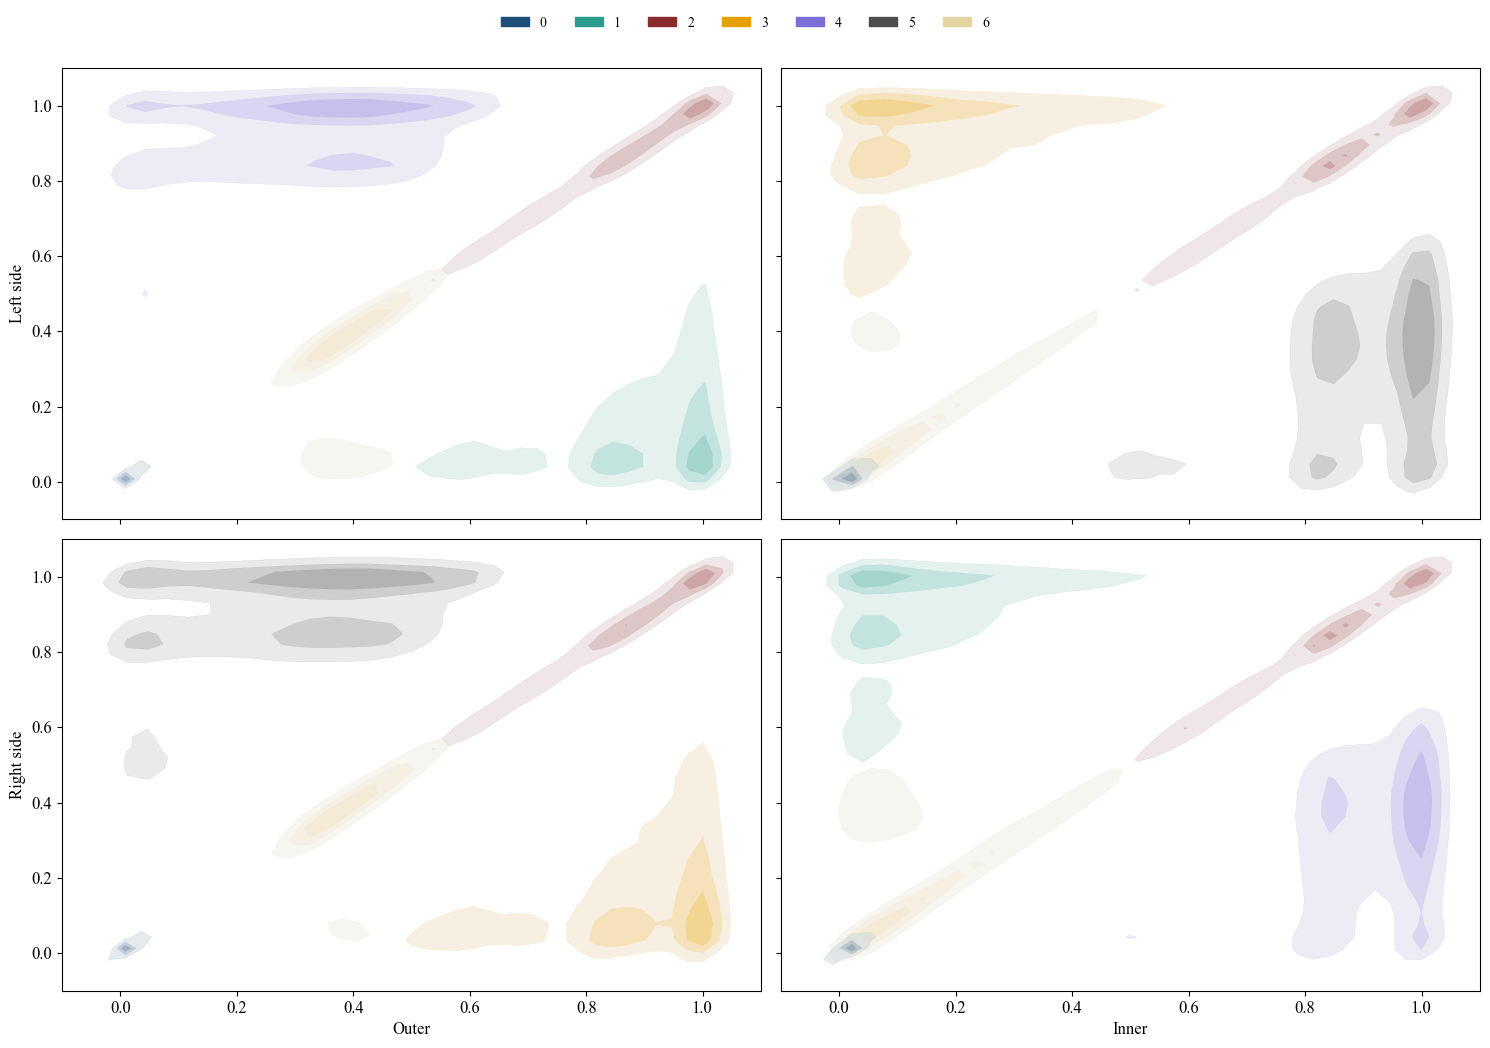

In [68]:
colors = ['#1f77b4', "#e69f00", "#b22222", "#ffae00", '#e69f00','#6a3d9a', '#e69f00']
colors = ['#1F4E79', '#2A9D8F',  '#8B2C2C','#E69F00', "#7B6ED6",'#4D4D4D', '#E6D3A3']
# xlab = ['Outer', 'Inner', 'Outer', 'Inner']
f,ax = plt.subplots(ncols = 2, nrows = 2, figsize = [15,10], squeeze = False, sharey = True, sharex = True)
ax = ax.flatten()
for i, comb in enumerate(combs):
    print(comb)
    for c in range(clusters):
        if kde_list[i][c] is not None:
            X, Y, Z = kde_list[i][c]

            ZRel = Z/Z.max()
            Z    = np.where(ZRel < 0.001, np.nan, ZRel)

            # Define contour levels ABOVE min_density
            Z_min = np.nanmin(Z)
            Z_max = np.nanmax(Z)
            n_levels = 4
            levels = np.linspace(Z_min, Z_max, n_levels)  # lowest contour starts above min_density
            levels = np.array([0.001, 0.25, 0.5, 0.75, 1.0])
            if all(levels == 0):
                continue
            # print(c, levels)
            # Filled contours (shades of one color)
            cmap = sns.light_palette(colors[c], as_cmap=True)
            if c == 0:
                zz = 1000
            else:
                zz = 10
            cf  = ax[i].contourf(X, Y, Z, levels=levels[1:], cmap=cmap, alpha = 0.5, antialiased = True, zorder = zz)
            # This is the fix for the white lines between contour levels
            # cf.set_edgecolor("face")
            # Contour lines (single color, skip lowest)
            
            ax[i].set_xlim([-0.1,1.1])
            ax[i].set_ylim([-0.1,1.1])
            # ax[i].set_xlabel(xlab[i], fontsize = labelSize)
            # ax[i].set_ylabel(axisLabels[comb[1]],fontsize = labelSize)
            ax[i].tick_params(axis='both', which='major', labelsize=tickSize)

            cs = ax[i].contour(X, Y, Z, levels=levels[0:], colors=colors[c], linewidths=0.07)

# Create legend handles manually (to ensure one instance of each label)

legendColors = colors
legendLabels = list(np.arange(len(colors)))
handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

# legendColors = ['blue', 'green', 'cyan', 'red']
# legendLabels = ['Unconfined','Asymmetrical partially confined','Symmetrical partially confined','Confined']
# handles = [Patch(color=legendColors[i], label=legendLabels[i]) for i, group in enumerate(np.arange(len(legendColors)))]

# Add shared legend at the top center
lgd = f.legend(
    handles=handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=8,
    frameon=False,
    title_fontsize = 12
)

ax[2].set_xlabel('Outer', fontsize = 12)
ax[3].set_xlabel('Inner', fontsize = 12)

ax[0].set_ylabel('Left side', fontsize = 12)
ax[2].set_ylabel('Right side', fontsize = 12)
plt.tight_layout()
# plt.savefig(f'/Users/6256481/Library/CloudStorage/OneDrive-UniversiteitUtrecht/Desktop/RivWidth/Paper/Figuren/'+f'KDE_confinement_clustering_{clusters}_all.png', bbox_extra_artists=(lgd,), bbox_inches='tight', dpi = 1000)
plt.show()